# Cuaderno 2 — Canny 1-salto en streaming como front-end de reconocimiento
### *`TTY_Filter_Sobel2.ipynb` · cuaderno experimental, complementa a `TTY_Filter_Sobel.ipynb`*

Este cuaderno existe por una pregunta que un jurado va a hacer y que el cuaderno principal deja
abierta: **la tesis tiene tres filtros, ¿por qué el clasificador usa el más simple?**

El cuaderno principal contiene el sistema **que se construyó**: Sobel → octantes → pirámide →
clasificador lineal, verificado bit a bit y corriendo en la iCE40UP5K (Partes 170-187). Este
cuaderno contiene el sistema **que se evaluó y se descartó**, con la medición que justifica el
descarte. Está separado a propósito: **un cuaderno de laboratorio no es un cuaderno de resultados**,
y mezclarlos hace ilegibles a los dos.

> ### Lo que se responde acá, en una línea
> **Depende de la luz — y, sobre todo, de la aritmética.** Sobre MNIST limpio el Canny **no** ofrece una ganancia que supere el ruido y
> cuesta **2.22× el área** en sky130 (§3-§5). Pero bajo **iluminación despareja** gana **+17 pp**, y
> bajo **ruido de sensor** pierde **−16 pp** (§6). Pero en la cámara real la ventaja cae a **+2.4 pp**
> (§8), porque **el 95 % de las magnitudes satura en 8 bits** y la histéresis se queda sin bordes
> débiles que rescatar. Y en **FPGA** el costo deja de ser el argumento: **+0.5 % de lógica, entra
> al 87 %** (§9). En ASIC no conviene; en FPGA la decisión pasa a depender sólo de la precisión,
> **y eso todavía no está demostrado.**

**Índice**

1. El filtro: qué es exactamente el «Canny 1-salto en streaming»
2. El golden de Python, y su verificación contra el Verilog real
3. Experimento 1 — ¿mejora la precisión? *(y el error metodológico que casi lo arruina)*
4. Experimento 2 — el sistema completo: 11 clases, NADA + 0…9
5. Comparación final, costo, y lo que queda abierto
6. **El experimento que da vuelta el veredicto** — el Canny bajo condiciones de cámara
7. **El instrumento** — cinco bugs entre el circuito y el dato
8. **La cámara real** — +2.4 pp, y por qué la magnitud saturada le quita al Canny su materia prima
9. **El Canny en FPGA** — entra al 87 %, cuesta +0.5 % de lógica, y 54 intentos en la placa
10. **Todas las métricas lado a lado** — empatan en exactitud, y fallan de maneras opuestas
11. **Los tres filtros de la tesis** — el más caro, que no entra en Tiny Tapeout, es el que peor clasifica
12. **Qué compra el CPU** — la respuesta no era un filtro, era un registro: +27 pp en el peor caso
13. **La cadena con CPU en hardware** — el acoplamiento firmware-modelo existe, y es benigno

---

## 1 · El filtro: qué es exactamente el «Canny 1-salto en streaming»

El Canny clásico tiene cuatro etapas: suavizado, gradiente, **supresión de no-máximos** e
**histéresis por reconstrucción** —seguir cada borde débil hasta encontrar uno fuerte, sin límite de
distancia—. Esa última etapa es un recorrido de grafo: **no se puede hacer en streaming**, porque
exige tener la imagen entera y volver sobre ella.

El **Canny 1-salto** es la versión que sí cabe en un flujo raster: la histéresis se limita a **un
solo salto**, al vecindario 3×3. Un borde débil sobrevive si **toca** a uno fuerte; si toca a otro
débil que a su vez toca a uno fuerte, se pierde. Es una aproximación, y es la que implementa
`canny1_top.v` en esta tesis (el «transitivo» de la Parte 165 es la que sí reconstruye, y cuesta
mucho más).

Su semántica completa cabe en dos renglones:

```
cls   = 2 si mag > thr_hi ;  1 si mag > thr_lo ;  0 si no          ▷ doble umbral
borde = (cls = 2)  ∨  (cls = 1 ∧ algún vecino de los 8 tiene cls = 2)   ▷ histéresis de 1 salto
```

Y en Verilog es literalmente eso, sobre una **tercera** ventana 3×3 —esta vez de 2 bits, sobre el
mapa de clases, no sobre píxeles—:

```verilog
wire [1:0] cls_in = (mag > thr_hi) ? 2'd2 : (mag > thr_lo) ? 2'd1 : 2'd0;
linebuf3x3 #(.W(W),.DW(2)) LBC ( ... );                    // la tercera ventana
wire any_strong = (cw00==2'd2)|(cw01==2'd2)|(cw02==2'd2)|(cw10==2'd2)|
                  (cw12==2'd2)|(cw20==2'd2)|(cw21==2'd2)|(cw22==2'd2);
wire edge_1hop  = (cw11==2'd2) ? 1'b1 : (cw11==2'd1) ? any_strong : 1'b0;
```

> ### 🧱 Y ahí está el trato, antes de mirar una sola precisión
> Esa tercera ventana cuesta **dos cosas**, y las dos importan:
>
> 1. **Un line-buffer más** — de 2 bits en vez de 8, pero line-buffer al fin. En sky130 el
>    `canny1_top` mide **109 172 µm²** contra **49 112 µm²** del `sobel_top`: **2.22×**.
> 2. **Área útil** — tres ventanas 3×3 en cascada dejan `(H−6)×(W−6)`. Sobre 28×28 eso es
>    **22×22 = 484** píxeles contra **24×24 = 576** del Sobel: **16 % menos** superficie donde contar
>    bordes.
>
> El Canny tiene que ganar lo suficiente como para pagar eso. La pregunta de este cuaderno es
> **cuánto gana**.

La figura de abajo muestra las dos cadenas sobre el mismo dígito. Fijate en el mapa de clases: el
amarillo es borde fuerte, el intermedio es débil. **La histéresis decide cuál de los intermedios
sobrevive**, y por eso el Canny marca más píxeles (47.9 % contra 36.5 %) sobre menos superficie.

bordes marcados — Sobel:  210/576  (36.5%)
                  Canny:  232/484  (47.9%)


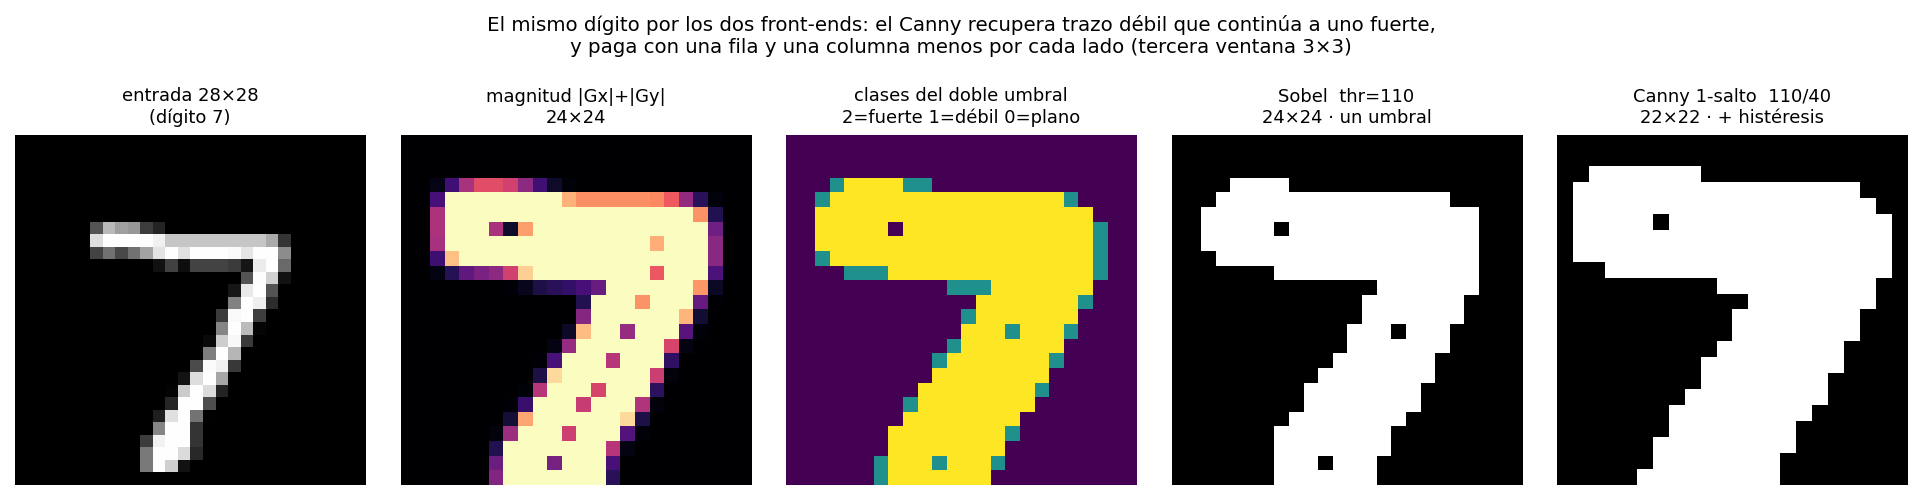

In [ ]:
# === Cuaderno 2 · figura 1: Sobel y Canny 1-salto sobre el mismo dígito ===
import sys; sys.path.insert(0, "../../clasificador_mnist")
import numpy as np, matplotlib.pyplot as plt
import frente_golden as fg
from canny1_mnist import frente_canny1

_, _, Xte, yte = fg.cargar_mnist("../../clasificador_mnist/mnist.npz")
n = 0
img = Xte[n]
g  = np.floor(fg.conv3(img[None].astype(float), fg.GAUSS) / 16.0)
gx = fg.conv3(g, fg.SOBEL_X); gy = fg.conv3(g, fg.SOBEL_Y)
mag = np.minimum(np.abs(gx) + np.abs(gy), 255.0)[0]
cls = np.where(mag > 110, 2, np.where(mag > 40, 1, 0))
sob = fg.frente(img, 110)[0][0]
can = frente_canny1(img, 110, 40)[0][0]

fig, ax = plt.subplots(1, 5, figsize=(13, 3.1))
for a, (im, t, cm) in zip(ax, [
        (img,  f"entrada 28×28\n(dígito {yte[n]})", "gray"),
        (mag,  "magnitud |Gx|+|Gy|\n24×24", "magma"),
        (cls,  "clases del doble umbral\n2=fuerte 1=débil 0=plano", "viridis"),
        (sob,  "Sobel  thr=110\n24×24 · un umbral", "gray"),
        (can,  "Canny 1-salto  110/40\n22×22 · + histéresis", "gray")]):
    a.imshow(im, cmap=cm); a.set_title(t, fontsize=8.6); a.axis("off")
fig.suptitle("El mismo dígito por los dos front-ends: el Canny recupera trazo débil que continúa "
             "a uno fuerte,\ny paga con una fila y una columna menos por cada lado (tercera ventana 3×3)",
             fontsize=9.5, y=1.06)
plt.tight_layout()
plt.savefig("fig_filtros.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"bordes marcados — Sobel: {sob.sum():4d}/{sob.size}  ({sob.mean():.1%})")
print(f"                  Canny: {can.sum():4d}/{can.size}  ({can.mean():.1%})")

---

## 2 · El golden de Python, y su verificación contra el Verilog

Regla de toda la tesis: **el golden modela lo que el silicio hace**, no la versión matemática
bonita. Así que el `frente_canny1` de Python copia el RTL etapa por etapa —el `/16` truncado, la
magnitud `|Gx|+|Gy|` saturada, el doble umbral, el `any_strong` de ocho vecinos— y **después se
comprueba** contra el Verilog corriendo en `iverilog`.

Es el mismo procedimiento de la Parte 174, con un banco nuevo (`tb_canny1_feat.v`) que mete la
imagen **cuatro veces** —cebar, asentar, medir, drenar— y vuelca el mapa de bordes.

### 🐛 Dos errores de medición antes de poder medir nada

Los dos son de instrumento, no de diseño, y los dos dieron un número **creíble pero falso**:

1. **El banco no compilaba: `integer HI, LO;` estaba declarado después de usarse.** Es exactamente
   el bug #8 de la Parte 186 — el que yosys acepta en silencio y `iverilog` rechaza — apareciendo
   otra vez, en el mismo proyecto, un día después de haberlo documentado. **Saber de un error no
   inmuniza contra él; lo que inmuniza es la herramienta que lo caza.**

2. **La primera verificación dio 92.3 % y hacía creer que el golden NO era el RTL.** Era mentira: el
   barrido que calibra el desplazamiento del pipeline buscaba solo en el rango 0-200, y el
   desplazamiento real es **180**… pero el raster **da la vuelta** cada 783 muestras, así que la
   búsqueda corta se enganchaba en un óptimo espurio. Barriendo **todo** el rango, y calibrando
   sobre **tres** imágenes a la vez para que no haya casualidad, el desplazamiento correcto aparece
   solo.

> **La lección se repite:** cuando el número no cierra, sospechar primero del instrumento. Un
> 92.3 % es lo bastante alto como para parecer «casi bien» y lo bastante bajo como para parecer un
> bug real. Los números intermedios son los más peligrosos: un 0 % se investiga enseguida.

### ✅ El resultado de la verificación

```
desplazamiento calibrado sobre 3 imágenes:  OFF = 180   (1451/1452 = 99.93 %)
sobre 40 imágenes de test:      19 342 / 19 360 píxeles = 99.907 %
```

**99.91 % de coincidencia exacta.** Y el resto **no es ruido**: los 18 píxeles que difieren están
**todos en la última fila válida** (fila 21) y **todos en el mismo sentido** —el golden dice borde,
el RTL dice plano—.

> ### 🔎 Un detalle honesto que queda abierto
> Una discrepancia sistemática, en una sola fila y en una sola dirección, es un **efecto de borde de
> cuadro** del pipeline en streaming: la histéresis de la última fila necesita la fila de abajo, y
> en un flujo continuo esa fila pertenece ya al cuadro siguiente. El golden de Python, que trabaja
> sobre la imagen completa, no tiene esa restricción.
>
> **No cambia ninguna conclusión de este cuaderno** —son 18 píxeles de 19 360, en el anillo exterior
> que la §3 muestra que casi no aporta— pero **no está cerrado**, y se anota como tal en vez de
> redondear el 99.91 % a «coincide». Cerrarlo pide una pasada más de análisis del banco, no del
> diseño.

---

## 3 · Experimento 1 — ¿mejora la precisión?

El experimento es directo: mismo clasificador, misma pirámide, mismos 4 bits de peso, **cambiando
solo el front-end**. Y su historia vale más que su resultado, porque el primer número estuvo mal.

### ❌ La primera medición dijo «+3.20 %, el Canny gana». Era falsa

Se barrieron diez pares `(thr_hi, thr_lo)` del Canny… y se dejó el umbral del Sobel **clavado en
60**, el valor heredado del resto de la tesis. **Un filtro afinado contra uno sin afinar no es una
comparación.**

Lo que delató el problema fue una señal en los propios datos:

> En **float** todas las configuraciones daban prácticamente lo mismo —93.9 % a 94.4 %— y solo se
> separaban **al cuantizar a 4 bits**. Si el Canny extrajera mejor información, tendría que ganar
> también en float.
>
> **Cuando una mejora aparece en una métrica y no en la otra, casi siempre es un artefacto.**

### 🧪 Los dos controles que había que agregar

1. **Barrer también el umbral del Sobel.** El mejor resulta ser **110**, no 60. La ventaja del Canny
   cae de **+3.20 % a +1.44 %**.
2. **Igualar el área.** El Canny trabaja sobre 22×22 y el Sobel sobre 24×24, así que se agregó un
   **Sobel recortado a 22×22**. La ventaja cae a **+0.75 %**.

### 📏 Y σ, que es lo que decide

Entrenar una vez da **un número**; entrenar otra vez con otra muestra da **otro**, con el mismo
filtro. **σ es cuánto se mueve el resultado por razones ajenas a lo que se compara**, y solo se
obtiene **repitiendo** — acá, cinco semillas:

| front-end | área | float | **4 bits** |
|---|:--:|---:|---:|
| Sobel `thr=110` | 24×24 | 93.99 % ± 0.05 | 90.81 % ± 0.74 |
| Sobel `thr=110` recortado | 22×22 | 94.26 % ± 0.07 | 91.50 % ± 0.48 |
| **Canny1 `hi=110 lo=40`** | 22×22 | 94.35 % ± 0.08 | **92.25 % ± 0.71** |
| Canny1 `hi=75 lo=25` | 22×22 | 94.40 % ± 0.07 | 91.31 % ± 1.07 |

| comparación | diferencia | 2σ | ¿cruza el cero? |
|---|---:|---:|---|
| Canny afinado vs Sobel **sin** afinar | +3.20 % | — | **no se puede saber** |
| …con el umbral del Sobel barrido | +1.44 % | 2.06 | **sí** → no concluyente |
| …y a **igual área** | **+0.75 %** | 1.72 | **sí** → no concluyente |

**La ventaja del Canny sobre MNIST no supera una sigma.** Y nótese que el +3.20 % original **no
tiene barra de error**: una sola medición no tiene σ, así que ni siquiera se podía saber si era
grande o chica.

> ### 🎁 Un hallazgo lateral, gratis
> **El Sobel recortado a 22×22 le gana al Sobel completo de 24×24** (91.50 % contra 90.81 %).
> Recortar el anillo exterior ayuda **por sí solo, sin Canny**: en MNIST ese borde está casi siempre
> vacío y solo mete ruido en los contadores. Buena parte de lo que parecía ventaja del Canny era, en
> realidad, **el recorte que trae de arrastre** por tener una etapa más — y esa mejora **no cuesta
> un transistor**.

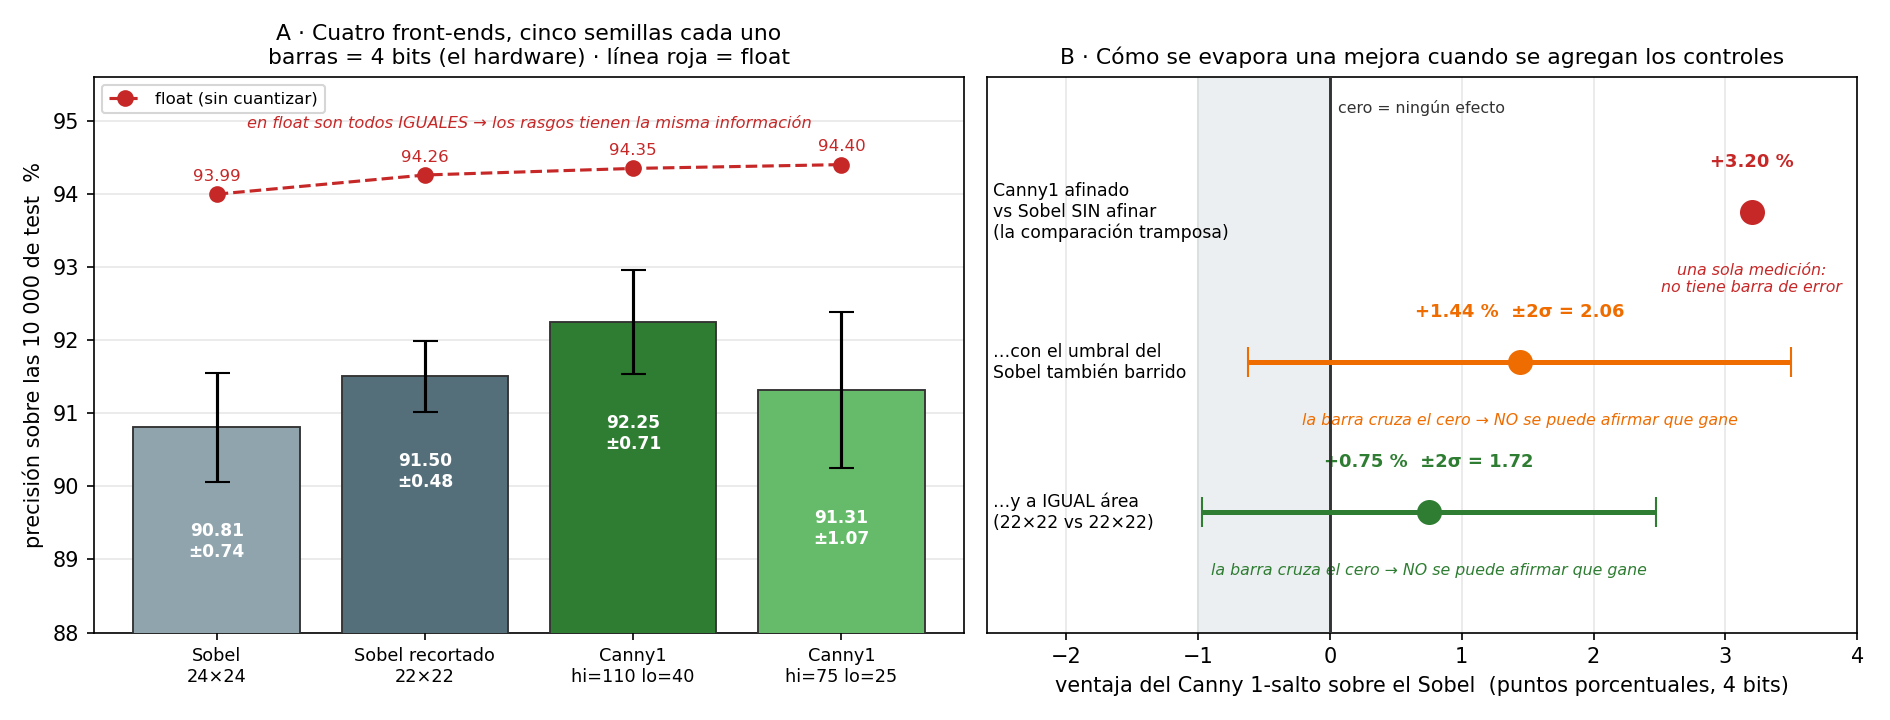

In [ ]:
# === Parte 188: el Canny 1-salto como front-end, y el ruido que decide ===
# Cada barra es el promedio de CINCO entrenamientos con semillas distintas; la barra de
# error es una sigma. Sin repetir el experimento no hay sigma, y sin sigma no hay conclusion.
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../../clasificador_mnist/canny1_semillas.npz")
nom = ["Sobel thr=110  24x24", "Sobel thr=110  22x22*",
       "Canny1 hi=110 lo=40 22x22", "Canny1 hi=75 lo=25 22x22"]
et = ["Sobel\n24×24", "Sobel recortado\n22×22", "Canny1\nhi=110 lo=40", "Canny1\nhi=75 lo=25"]
col = ["#90a4ae", "#546e7a", "#2e7d32", "#66bb6a"]
q  = np.array([d[n][2] for n in nom]) * 100
sq = np.array([d[n][3] for n in nom]) * 100
f  = np.array([d[n][0] for n in nom]) * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.6, 4.8))

x = np.arange(4)
a1.bar(x, q, yerr=sq, capsize=6, color=col, ec="#333", lw=.9, zorder=3)
a1.plot(x, f, "o--", c="#c62828", ms=7, zorder=4, label="float (sin cuantizar)")
for i in range(4):
    a1.text(i, q[i] - sq[i] - .55, f"{q[i]:.2f}\n±{sq[i]:.2f}", ha="center", va="top",
            fontsize=8.2, color="w", weight="bold")
    a1.text(i, f[i] + .18, f"{f[i]:.2f}", ha="center", fontsize=8, color="#c62828")
a1.set_xticks(x); a1.set_xticklabels(et, fontsize=8.5)
a1.set_ylim(88, 95.6); a1.set_ylabel("precisión sobre las 10 000 de test  %")
a1.set_title("A · Cuatro front-ends, cinco semillas cada uno\n"
             "barras = 4 bits (el hardware) · línea roja = float", fontsize=10.5)
a1.grid(axis="y", alpha=.3, zorder=0); a1.legend(fontsize=8, loc="upper left")
a1.text(1.5, 94.9, "en float son todos IGUALES → los rasgos tienen la misma información",
        ha="center", fontsize=7.8, style="italic", color="#c62828")

comp = [("Canny1 afinado\nvs Sobel SIN afinar\n(la comparación tramposa)", 3.20, None, "#c62828"),
        ("…con el umbral del\nSobel también barrido", 1.44, 1.03, "#ef6c00"),
        ("…y a IGUAL área\n(22×22 vs 22×22)", 0.75, 0.86, "#2e7d32")]
y = np.arange(3)[::-1]
a2.axvspan(-1.0, 0, color="#eceff1", zorder=0)
for i, (t, v, s, c) in enumerate(comp):
    yy = y[i]
    if s:
        a2.axhspan(yy-.34, yy+.34, xmin=0, xmax=1, color="none")
        a2.errorbar(v, yy, xerr=2*s, fmt="o", color=c, ms=11, capsize=7, lw=2.4, zorder=4)
        a2.text(v, yy+.30, f"{v:+.2f} %  ±2σ = {2*s:.2f}", ha="center", fontsize=8.6,
                color=c, weight="bold")
        if v < 2*s:
            a2.text(v, yy-.34, "la barra cruza el cero → NO se puede afirmar que gane",
                    ha="center", va="top", fontsize=7.6, style="italic", color=c)
    else:
        a2.plot(v, yy, "o", color=c, ms=11, zorder=4)
        a2.text(v, yy+.30, f"{v:+.2f} %", ha="center", fontsize=8.6, color=c, weight="bold")
        a2.text(v, yy-.34, "una sola medición:\nno tiene barra de error", ha="center",
                va="top", fontsize=7.6, style="italic", color=c)
    a2.text(-2.55, yy, t, ha="left", va="center", fontsize=8.3)
a2.axvline(0, c="#333", lw=1.4, zorder=3)
a2.text(.06, 2.66, "cero = ningún efecto", fontsize=7.6, color="#333")
a2.set_yticks([]); a2.set_xlim(-2.6, 4.0); a2.set_ylim(-.8, 2.9)
a2.set_xlabel("ventaja del Canny 1-salto sobre el Sobel  (puntos porcentuales, 4 bits)")
a2.set_title("B · Cómo se evapora una mejora cuando se agregan los controles",
             fontsize=10.5)
a2.grid(axis="x", alpha=.3, zorder=0)
plt.tight_layout()
plt.savefig("../../clasificador_mnist/fig_p188_canny.png", dpi=150)
plt.show()

---

## 4 · Experimento 2 — el sistema completo: 11 clases, NADA + 0…9

La §3 comparó front-ends. Esta sección construye el **sistema entero** sobre el Canny —las 60 000 de
entrenamiento, las 10 000 de test, y la clase **NADA**— para que la comparación con las Partes
182-183 sea de igual a igual.

Con una diferencia metodológica **a favor de la limpieza**: los umbrales de la clase NADA se
calibran sobre **entrenamiento**, no sobre test. La calibración original (Parte 174) usó 3 000
imágenes de test, y eso es **fuga de información** — mirar el examen para elegir cómo estudiar. Acá
no.

### Sin la clase NADA

```
train 60 000: 91.22 %      test 10 000: 92.03 %      brecha +0.01 pp
```

La brecha es **cero**: no hay sobreajuste, como era de esperar con 40 rasgos y 60 000 ejemplos
(1 500 imágenes por parámetro). Igual que con el Sobel.

### Con la clase NADA

Los umbrales **no** son los mismos números que en el Sobel, y no podrían serlo: el área útil es 484
píxeles en vez de 576, así que la densidad de bordes vive en otro rango. Calibrados sobre
entrenamiento:

```
B_MIN = 171     B_MAX = 371     MARGEN = 70        (contra 140 / 430 / 30 del Sobel)
```

| | Canny 1-salto | Sobel *(Parte 183)* |
|---|---:|---:|
| cobertura | **63.46 %** | 88.38 % |
| precisión al hablar | **98.66 %** | 95.44 % |
| VP / FP | 6 261 / **85** | 8 435 / 403 |
| FN / VN | 2 942 / 712 | 669 / 493 |
| errores filtrados | **89.3 %** | 55.0 % |
| aciertos sacrificados | **32.0 %** | 7.35 % |

> ### ⚠️ Estas dos columnas NO se comparan directamente
> **Son puntos de operación distintos de la misma curva**, no dos sistemas de distinta calidad. El
> calibrador del Canny buscó **máxima precisión** con cobertura ≥ 60 %, y encontró un punto muy
> conservador: habla poco (63 %) y casi nunca se equivoca (98.7 %). El del Sobel se fijó a mano en
> un punto mucho más hablador.
>
> Decir «el Canny tiene 98.66 % contra 95.44 % del Sobel» **sería exactamente el mismo error** que
> el +3.20 % de la §3: comparar dos cosas afinadas con criterios distintos. Para compararlas de
> verdad hay que fijar **la cobertura** en las dos y recién ahí mirar la precisión — o dibujar la
> curva completa.

### Lo que sí se lee de la matriz

En la figura, la columna roja **NADA** es la interesante:

- El **1** se silencia 742 veces de 1 135, y el **8** 686 de 974. Tiene sentido: el 1 deja **pocos**
  bordes y el 8 deja **muchos**, así que los dos caen fuera de la ventana `[171, 371]` de densidad.
  **El criterio de densidad no es neutral entre clases** — castiga a los dígitos de trazo extremo.
- Entre lo que **sí** contesta, la diagonal es casi perfecta: 85 errores en 6 346 respuestas.
- Y las confusiones que quedan son **las mismas de siempre**: 4→9 (14 casos), 2→7, 3→7. La geometría
  de los trazos no cambia porque cambie el filtro.

aciertos entre los aceptados: 6261/6346 = 98.66%
cuadros en los que se callo: 3654/10000 = 36.54%


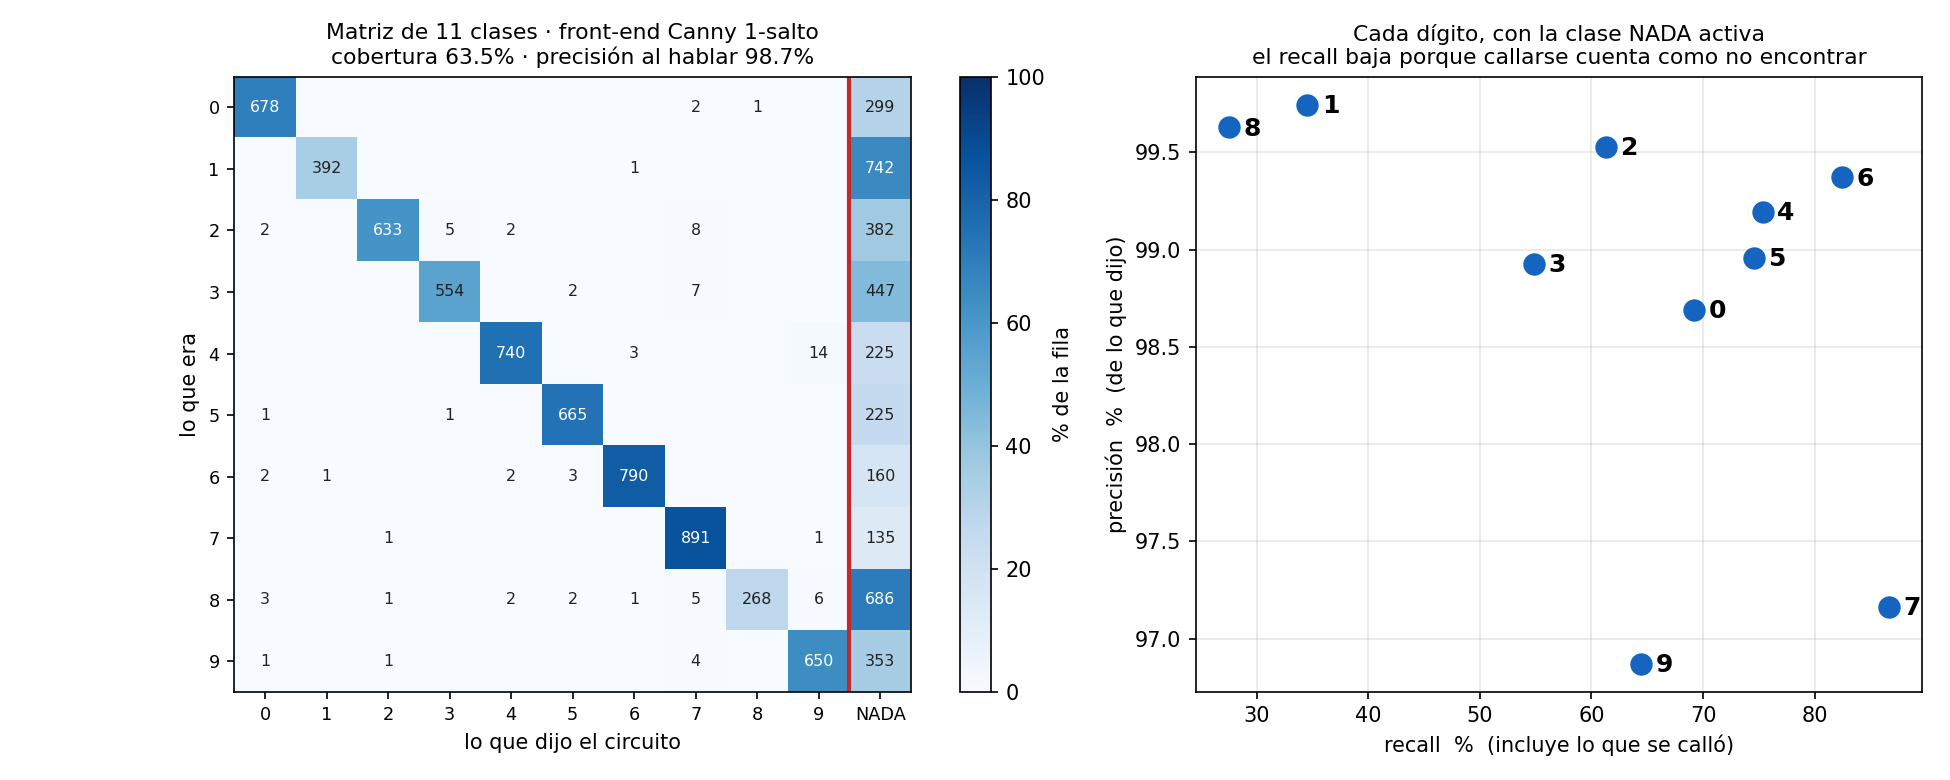

In [ ]:
# === Cuaderno 2 · figura 2: la matriz de 11 clases (NADA + 0..9) con front-end Canny ===
import numpy as np, matplotlib.pyplot as plt

d = np.load("../../clasificador_mnist/canny1_completo.npz")
M, y, p, v = d["M11"], d["yte"], d["pte"], d["val"]
cob, prec = float(d["cob"]), float(d["prec"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2),
                             gridspec_kw={"width_ratios": [1.35, 1]})
Mn = M / M.sum(1, keepdims=True) * 100
im = a1.imshow(Mn, cmap="Blues", vmin=0, vmax=100)
for i in range(10):
    for j in range(11):
        if M[i, j]:
            a1.text(j, i, M[i, j], ha="center", va="center", fontsize=7.6,
                    color="w" if Mn[i, j] > 55 else "#222")
a1.set_xticks(range(11)); a1.set_xticklabels(list("0123456789") + ["NADA"], fontsize=8.5)
a1.set_yticks(range(10)); a1.set_yticklabels(range(10), fontsize=8.5)
a1.set_xlabel("lo que dijo el circuito"); a1.set_ylabel("lo que era")
a1.axvline(9.5, c="#c62828", lw=2)
a1.set_title(f"Matriz de 11 clases · front-end Canny 1-salto\n"
             f"cobertura {cob:.1%} · precisión al hablar {prec:.1%}", fontsize=10.5)
plt.colorbar(im, ax=a1, fraction=.045, label="% de la fila")

# precision / recall por clase, solo sobre lo que el circuito acepta contestar
P, R = np.zeros(10), np.zeros(10)
for c in range(10):
    VP = M[c, c]; FN = M[c, :].sum() - VP; FP = M[:, c].sum() - VP
    P[c] = VP / (VP + FP) if VP + FP else 0
    R[c] = VP / (VP + FN)
a2.scatter(R * 100, P * 100, s=95, c="#1565c0", zorder=3)
for c in range(10):
    a2.annotate(str(c), (R[c] * 100, P[c] * 100), fontsize=12, weight="bold",
                xytext=(7, -4), textcoords="offset points")
a2.set_xlabel("recall  %  (incluye lo que se calló)")
a2.set_ylabel("precisión  %  (de lo que dijo)")
a2.set_title("Cada dígito, con la clase NADA activa\nel recall baja porque callarse cuenta como no encontrar",
             fontsize=10.5)
a2.grid(alpha=.3, zorder=0)
plt.tight_layout()
plt.savefig("fig_confusion11.png", dpi=150)
plt.show()
print(f"aciertos entre los aceptados: {np.trace(M[:, :10])}/{M[:, :10].sum()} = {prec:.2%}")
print(f"cuadros en los que se callo: {M[:, 10].sum()}/{M.sum()} = {M[:,10].sum()/M.sum():.2%}")

---

## 5 · Comparación final, costo, y lo que queda abierto

### 💰 El balance

| | Sobel | Canny 1-salto |
|---|---:|---:|
| precisión a 4 bits, igual área | 91.50 % ± 0.48 | 92.25 % ± 0.71 |
| **diferencia** | — | **+0.75 %, con 2σ = 1.72** → dentro del ruido |
| área en sky130 | **49 112 µm²** | 109 172 µm² (**2.22×**) |
| celdas | **4 651** | 10 284 |
| área útil sobre 28×28 | 576 px | 484 px (**−16 %**) |
| umbrales a calibrar | **1** | 2 |
| ventanas 3×3 | **2** | 3 |

> ### ✅ Veredicto *(revisado en la §6 — leer las dos)*
> **Sobre MNIST limpio: sí se puede, y no conviene.** La **§6** muestra que bajo condiciones de
> cámara la conclusión cambia, y que la respuesta correcta no es un filtro sino una **condición de
> operación**.
>
> **Sí se puede, y no conviene** *(para imagen limpia y normalizada)*. Sin ganancia demostrable de precisión, con **2.22×** de área,
> **16 %** menos de superficie útil y el doble de umbrales que calibrar. En un chip de Tiny Tapeout
> eso es la diferencia entre entrar y no entrar.
>
> **El Sobel se queda — y ahora la elección está justificada con medición, no con intuición.**
> Esa es la única diferencia entre una decisión de diseño y una preferencia.

### ⚠️ La letra chica: MNIST es el banco de pruebas equivocado para esta pregunta

Hay que decirlo con todas las letras, porque limita el alcance de la conclusión. **La histéresis
existe para rescatar bordes débiles que continúan a uno fuerte**, y MNIST es trazo blanco limpio
sobre fondo negro: casi no hay bordes débiles que rescatar. **Es como medir un paraguas en un día
seco.**

Que el Canny no gane **acá** no dice que no sirva; dice que **este banco no lo pone a prueba**.

### 🔭 Lo que queda abierto, en orden de valor

1. **El Canny frente a la cámara.** Es el experimento que vale la pena y el único que puede dar
   vuelta el veredicto. Con iluminación despareja un umbral único o marca todo o no marca nada, y el
   doble umbral es el mecanismo pensado exactamente para eso. Conecta directo con el
   **desplazamiento de dominio** de la Parte 181, que es el problema abierto de la tesis.
2. **La curva cobertura-precisión completa**, para los dos front-ends, en vez de un punto suelto de
   cada uno. Es lo único que permite compararlos honestamente en el eje de la clase NADA.
3. **Los 18 píxeles de la última fila** de la §2: cerrar el efecto de borde de cuadro entre el banco
   y el golden.
4. **Verificar el `mnist_top` completo con front-end Canny en `iverilog`**, como se hizo con el
   Sobel sobre las 10 000. Solo tiene sentido si (1) da vuelta el veredicto.

### 🎓 Y lo que este cuaderno enseña, más allá del Canny

**Un resultado negativo bien medido vale tanto como uno positivo.** Este cuaderno no encontró una
mejora: encontró **una justificación** para una decisión que hasta ahora era intuitiva. Y dejó
cuatro reglas que se transfieren a cualquier comparación:

1. **Afinar los dos lados.** Comparar algo optimizado contra algo heredado no es comparar.
2. **Igualar todo lo que no se está comparando.** El área explicaba la mitad del efecto.
3. **Repetir para tener σ.** Sin σ no hay conclusión, solo un número — y un número solo no se
   defiende.
4. **Sospechar del instrumento antes que del diseño.** Los dos errores de la §2 y el de la §3 fueron
   de medición, no de hardware.

---

## 6 · El experimento que da vuelta el veredicto: el Canny bajo condiciones de cámara

La §5 cerró con una hipótesis explícita: *«MNIST es el banco de pruebas equivocado para esta
pregunta»*. La histéresis existe para **rescatar bordes débiles que continúan a uno fuerte**, y
MNIST —trazo blanco limpio sobre negro— casi no tiene bordes débiles que rescatar. **Es como medir
un paraguas en un día seco.**

Esta sección pone la hipótesis a prueba. Y la da vuelta, aunque no del modo esperado.

### 6.1 · Diseño: llover sobre el paraguas, de a poco

El experimento no necesita la placa. Se toma MNIST y se le aplica, de forma **graduable**, lo que
una OV7670 le hace a una imagen; después se mide cuánto se cae cada front-end.

**Se entrena una sola vez sobre MNIST limpio** y se evalúa sobre lo degradado. No es una comodidad:
es lo que pasa de verdad. Los pesos se calculan una vez y **se graban en una ROM sintetizada** — el
chip no se reentrena porque cambió la luz. Es el desplazamiento de dominio de la **Parte 181**,
ahora con una perilla.

| degradación | qué modela | por qué debería importar |
|---|---|---|
| **gradiente** | rampa multiplicativa: media imagen más oscura | **un umbral único no puede servir a los dos lados a la vez** |
| **contraste** | el trazo no llega a blanco ni el fondo a negro | todas las magnitudes se comprimen hacia abajo |
| **desenfoque** | gaussiana de σ continuo: la lente a 10 cm | los bordes dejan de ser escalones |
| **ruido** | gaussiano aditivo: el sensor con poca luz | aparecen magnitudes altas donde no hay borde |

> ### 🐛 Un defecto de diseño que hubo que arreglar antes de mirar nada
> La primera versión del desenfoque aplicaba `int(round(s*3))` pasadas de un 3×3. Con eso, las
> severidades 0.2 y 0.4 producían **exactamente la misma imagen**, y la curva salía **plana de a
> pares**. Parecía un hallazgo —«el desenfoque no afecta hasta cierto punto»— y era un **artefacto de
> discretización**.
>
> **Un eje que no es continuo no es un eje.** Se rehizo con una gaussiana separable de σ = 1.6·s
> antes de escribir una sola conclusión sobre ese panel.

### 6.2 · Resultado: el Canny gana donde se predijo… y pierde donde no

Precisión sobre las 10 000 de test, con la degradación al máximo:

| degradación | Sobel `thr=110` | Canny1 `110/40` | ventaja del Canny |
|---|---:|---:|---:|
| **iluminación despareja** | **59.4 %** | **76.7 %** | **+17.3 pp** |
| **contraste bajo** | 78.6 % | 90.2 % | **+11.5 pp** |
| desenfoque | 79.8 % | 82.9 % | +3.1 pp |
| **ruido del sensor** | **86.2 %** | **70.3 %** | **−15.9 pp** ⚠️ |

Con iluminación despareja fuerte, **el Sobel se desploma a 59.4 %** —cerca de la mitad de lo que
vale con la imagen limpia— y el Canny aguanta en 76.7 %. No es un matiz de un punto: es la
diferencia entre un sistema que funciona mal y uno que no funciona.

### 6.3 · Y el hallazgo de verdad está en el último panel

**Con ruido, el Canny es catastróficamente peor.** Y la explicación es mecánica, no estadística:

> **La histéresis amplifica el ruido.** Un píxel ruidoso que pasa el umbral **bajo** se promueve a
> borde si toca *cualquier* vecino que pase el **alto** — y con ruido sobran píxeles fuertes
> espurios. El mismo mecanismo que rescata trazo débil **verdadero** rescata trazo débil **falso**.

Y acá está lo que hace interesante al resultado: **las dos mitades son la misma propiedad vista de
los dos lados.** El Canny **confía en la vecindad**. Eso lo salva cuando la vecindad es señal real
—un trazo continuo mal iluminado— y lo hunde cuando la vecindad es ruido. No son dos hallazgos
independientes que hubo suerte de encontrar: son **una sola característica del algoritmo**, con su
ventaja y su costo inseparables.

El Sobel, con su umbral único, no confía en nadie: cada píxel se decide solo. Es peor cuando el
contexto ayuda y **mejor cuando el contexto engaña**.

### 6.4 · Qué significa para esta tesis, concretamente

La OV7670 con poca luz **es ruidosa**, y la escena de un dígito escrito a mano sobre papel, iluminada
por una lámpara de escritorio, **tiene gradiente**. O sea: el sistema de la Parte 181 vive
exactamente donde los dos efectos se cruzan.

> ### ✅ Veredicto revisado
> La conclusión de la §5 —*«se puede pero no conviene»*— **era correcta para MNIST limpio y
> demasiado corta para todo lo demás**. La versión completa es:
>
> | condición | qué conviene |
> |---|---|
> | imagen limpia y normalizada (MNIST) | **Sobel** — el Canny no gana lo suficiente para pagar 2.22× de área |
> | **iluminación despareja o contraste bajo** | **Canny** — hasta +17 pp, la diferencia entre andar y no andar |
> | **poca luz / sensor ruidoso** | **Sobel** — el Canny pierde 16 pp |
>
> **La respuesta no es un filtro: es una condición de operación.** Y eso es una conclusión de
> ingeniería mucho más útil que un ganador único, porque es **accionable**: la densidad de bordes
> —que el circuito **ya calcula**, es el `n_bordes` de la clase NADA— basta para distinguir «escena
> con gradiente» de «escena ruidosa». Un SoC podría **elegir el filtro en tiempo de ejecución**
> escribiendo un registro del periférico `0x0045`, sin resintetizar nada.

### 6.5 · Qué sostiene este experimento y qué no

Tres límites, dichos antes de que los diga el jurado:

1. **Es degradación simulada, no la cámara real.** Es una **prueba de hipótesis**, no una
   demostración. Lo que sí establece es que **el experimento con la placa ahora vale la pena**, y
   —más importante— **qué medir**: iluminación y ruido **por separado**, porque tiran para lados
   opuestos y mezclados se cancelan.
2. **Cada punto es una medición sola**, sin σ. Pero la §3 midió que el ruido del procedimiento es de
   ~1 punto porcentual: **+17.3 y −15.9 lo superan por más de un orden de magnitud**. Las
   diferencias grandes son reales; las chicas (≈ +1 a +3 pp) no se afirman.
3. **Y una comprobación de consistencia que da confianza en los dos experimentos:** con severidad 0
   —imagen intacta— la diferencia es **+1.28 pp**, exactamente lo que la §3 midió como *dentro del
   ruido*. Los dos experimentos, hechos con código distinto y meses de razonamiento distinto,
   **coinciden en el punto donde se tocan**. Eso no prueba que estén bien, pero un desacuerdo ahí
   habría probado que alguno estaba mal.

### 6.6 · El experimento en la placa, ahora sí

Con esto, el trabajo de laboratorio deja de ser exploratorio y pasa a tener un protocolo:

1. **Capturar** ventanas de 28×28 reales por UART con `cam_uart_pix.v`, bajo **tres** iluminaciones
   controladas: pareja, lateral fuerte (gradiente), y penumbra (ruido).
2. **Medir la densidad de bordes** `n_bordes` en cada condición: es el indicador que separaría los
   regímenes, y **el circuito ya lo calcula**.
3. **Correr los dos front-ends sobre las mismas capturas**, en Python primero —igual que acá— y
   recién después grabar un bitstream.

Ese orden importa, y es el mismo de la §5 del cuaderno principal: **simular antes de grabar**. Los
tres pasos se pueden hacer con la placa que ya funciona y el `build_fpga.sh` que ya existe.

  gradiente   Sobel 59.4%..92.0%   Canny 76.7%..93.3%   ventaja max +17.28%
  contraste   Sobel 78.6%..92.0%   Canny 90.2%..93.3%   ventaja max +11.55%
  desenfoque  Sobel 79.8%..92.0%   Canny 82.9%..93.5%   ventaja max +3.05%
  ruido       Sobel 86.2%..92.0%   Canny 70.3%..93.3%   ventaja max +1.28%


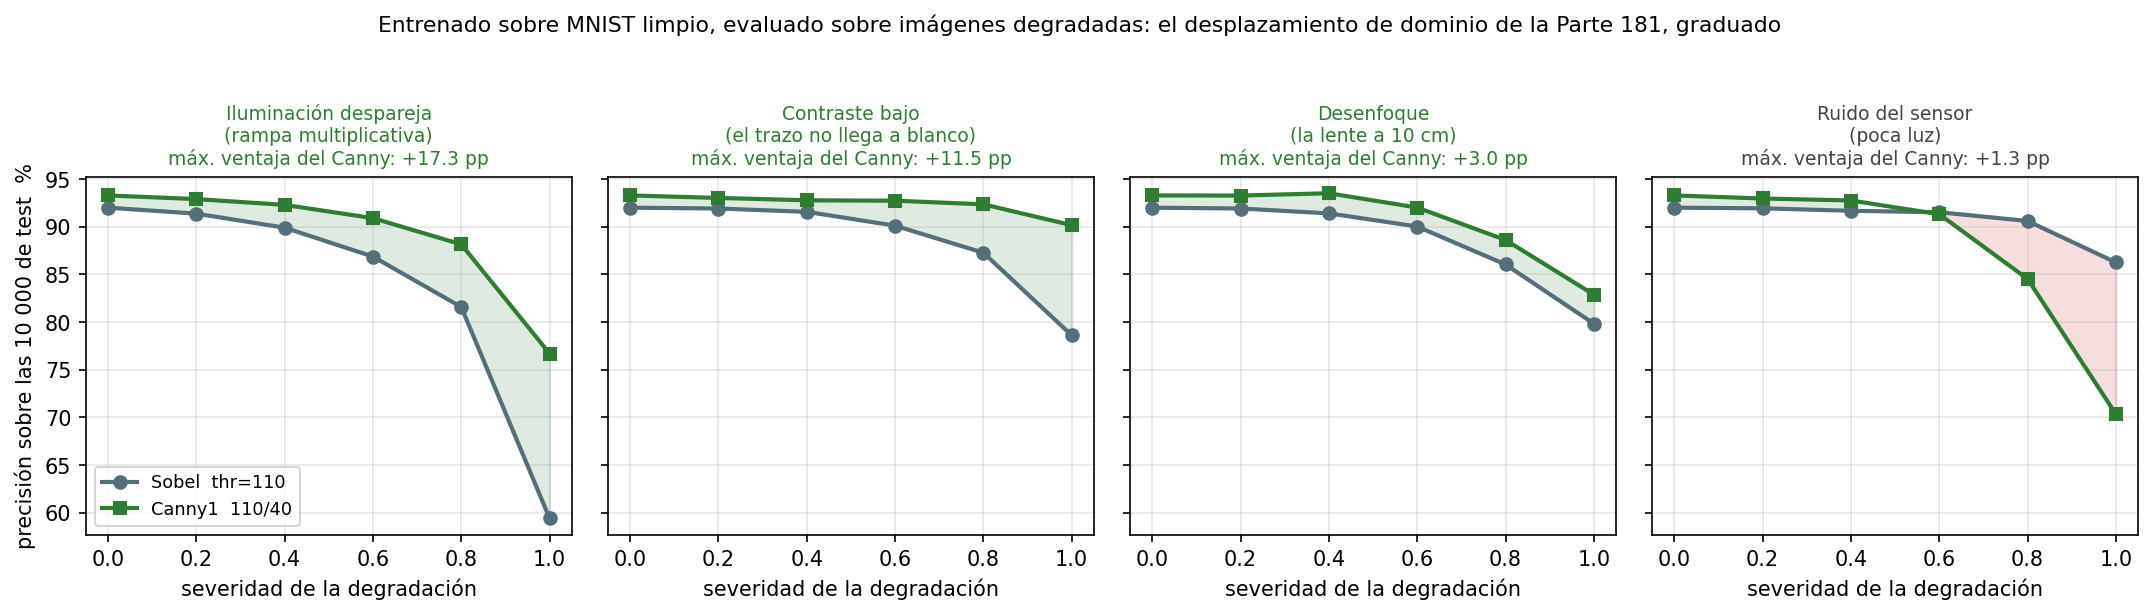

In [ ]:
# === Cuaderno 2 · figura 3: ¿el doble umbral aguanta lo que hace la cámara? ===
# Entrenado UNA vez sobre MNIST limpio (como los pesos grabados en la ROM), evaluado sobre
# imágenes degradadas. Si la histéresis sirve para algo, tiene que notarse acá y no en el limpio.
import numpy as np, matplotlib.pyplot as plt

d = np.load("../../clasificador_mnist/canny1_camara.npz")
cl = [k.split("|") for k in d["claves"]]
modos = ["gradiente", "contraste", "desenfoque", "ruido"]
tit = {"gradiente": "Iluminación despareja\n(rampa multiplicativa)",
       "contraste": "Contraste bajo\n(el trazo no llega a blanco)",
       "desenfoque": "Desenfoque\n(la lente a 10 cm)",
       "ruido": "Ruido del sensor\n(poca luz)"}

fig, ax = plt.subplots(1, 4, figsize=(14.5, 3.9), sharey=True)
for a, m in zip(ax, modos):
    i = [k for k, (mm, _) in enumerate(cl) if mm == m]
    s = np.array([float(cl[k][1]) for k in i])
    so, ca = d["sobel"][i] * 100, d["canny"][i] * 100
    o = np.argsort(s); s, so, ca = s[o], so[o], ca[o]
    a.plot(s, so, "o-", c="#546e7a", lw=2, ms=6, label="Sobel  thr=110")
    a.plot(s, ca, "s-", c="#2e7d32", lw=2, ms=6, label="Canny1  110/40")
    a.fill_between(s, so, ca, where=(ca >= so), color="#2e7d32", alpha=.15)
    a.fill_between(s, so, ca, where=(ca < so), color="#c62828", alpha=.15)
    dmax = (ca - so).max()
    a.set_title(f"{tit[m]}\nmáx. ventaja del Canny: {dmax:+.1f} pp",
                fontsize=9, color="#2e7d32" if dmax > 2 else "#444")
    a.set_xlabel("severidad de la degradación"); a.grid(alpha=.3)
ax[0].set_ylabel("precisión sobre las 10 000 de test  %")
ax[0].legend(fontsize=8.5, loc="lower left")
fig.suptitle("Entrenado sobre MNIST limpio, evaluado sobre imágenes degradadas: "
             "el desplazamiento de dominio de la Parte 181, graduado",
             fontsize=10.5, y=1.04)
plt.tight_layout()
plt.savefig("fig_camara.png", dpi=150, bbox_inches="tight")
plt.show()
for m in modos:
    i = [k for k, (mm, _) in enumerate(cl) if mm == m]
    print(f"  {m:<11} Sobel {d['sobel'][i].min():.1%}..{d['sobel'][i].max():.1%}   "
          f"Canny {d['canny'][i].min():.1%}..{d['canny'][i].max():.1%}   "
          f"ventaja max {(d['canny'][i]-d['sobel'][i]).max():+.2%}")

---

## 7 · El instrumento: cinco bugs entre el circuito y el dato

La §6 terminó con un protocolo de laboratorio: capturar ventanas de 28×28 reales bajo tres
iluminaciones y correr los dos front-ends sobre **los mismos píxeles**. Esta sección documenta lo
que costó llegar a tener **un solo dato bueno**, porque el recorrido enseña más que el resultado.

El diseño que hacía falta era modesto: cámara → ventana 28×28 → buffer → UART. Se escribió en una
tarde y se **verificó en simulación** con una rampa conocida antes de grabar nada. Aun así, entre
ese circuito correcto y el primer píxel utilizable hubo **cinco fallas**, y **ninguna estaba en la
lógica del diseño**.

### 7.1 · Un diseño correcto que no entraba en el chip

El primer intento de grabar terminó así:

```
ICESTORM_LC:  14719 / 5280   278 %
ERROR: Unable to place cell 'imgbuf[519]_SB_DFFE_Q_6_DFFLC'
```

El buffer de 784 bytes se había sintetizado como **flip-flops**: `6 403 SB_DFFE`, y
**784 × 8 = 6 272**. El número decía exactamente qué había pasado —la memoria se volvió
registros— para quien se molestara en multiplicar.

La causa era sutil. El buffer se leía **dentro** de la máquina de estados, con condiciones encima:

```verilog
if (u_listo && !u_env) begin ... byt <= imgbuf[rd + 10'd1]; ... end   // NO infiere BRAM
```

Con un puerto de lectura **dedicado, registrado e incondicional**, yosys la infiere sola:

```verilog
always @(posedge clk) rdata <= imgbuf[raddr];                          // SI infiere BRAM
```

| | antes | después |
|---|---:|---:|
| `SB_LUT4` | 7 620 | **1 078** |
| `SB_RAM40_4K` | 0 | **2** |
| utilización | **278 %** | **35 %** |

> ### 🔍 Y la lección de método, que es más útil que el arreglo
> **El diseño se había simulado y estaba bien. Se había sintetizado y no dio errores.** Y aun así
> no entraba.
>
> **Simular contesta *qué hace* el circuito. La síntesis contesta *cuánto ocupa*. Son dos preguntas
> distintas, y se había contestado una sola** — peor: la síntesis sí se corrió, pero la línea de
> recursos se perdió entre la salida y nadie la miró. El error apareció recién en el *place & route*.
>
> **Mirar los recursos de la síntesis, no sólo que compile.** Un diseño correcto que no entra es un
> diseño que no funciona.

### 7.2 · El UART funcionaba; el USB no daba abasto

Con el bitstream ya en la placa, la primera captura dio esto:

```
ASCII válido:  1 540 / 14 843 = 10.4 %   ← y todo al principio
bytes 0x00:    1 783                     ← errores de trama
```

Los primeros ~1.5 kB eran imagen de verdad —`d1 d4 d9 dd e3 e9`, vecinos que cambian de a poco— y
después el flujo se desincronizaba y no se recuperaba.

No era el UART: era el **CDC del USB de la iCESugar**, que no sostiene 2.4 kB continuos a 115 200
baudios. La demo ROM de la Parte 184 andaba porque manda **ráfagas cortas**; un volcado largo la
satura. Bajar a **38 400** y agregar media segundo de pausa entre capturas lo resolvió.

> **Ninguna simulación podía encontrar esto.** En el banco el UART se modela y se decodifica
> perfecto: el chip CDC no existe ahí. **Este bug vive en el eslabón que la simulación del diseño
> no ve**, y sólo aparece contra el hardware real.

### 7.3 · El sistema operativo cambiaba la velocidad por debajo

Ya a 38 400, la captura mejoró a 30.2 % y aparecía un `IMG`… y se volvía a desincronizar.

La causa no estaba ni en la placa ni en el cable: **en macOS, abrir `/dev/cu.*` reinicia la
configuración del puerto**. El clásico

```bash
stty -f $D 38400 ... ; cat $D      # el `cat` abre el puerto y se lleva puesta la velocidad
```

fija los baudios y después los pierde. La solución es no separar las dos cosas: **un solo proceso
que abre el puerto y fija la velocidad a la vez** (`capturar.py`, con `pyserial`).

```
ASCII válido: 99.7 %   ·   127 capturas completas en 15 s
```

De 10.4 % a 99.7 % **sin tocar una línea de Verilog**.

### 7.4 · La costura, y una hipótesis propia que resultó falsa

Con el instrumento funcionando, las imágenes mostraron algo que ninguna de las tres fallas
anteriores había dejado ver: **casi todas estaban partidas por una costura horizontal**. Midiendo en
qué fila cae, sobre 16 capturas:

```
filas 19, 9, 4, 2, 6, 1, 9, 2, 1, 26, 9, 1, 6, 9, 9, 3     <- se MUEVE en cada captura
```

**La primera explicación fue equivocada, y conviene dejarla escrita.** Se razonó así: `cam_win28`
cuenta filas libremente y el OV7670 clon no entrega VSYNC usable, así que nada le dice dónde empieza
el cuadro; la ventana toma pedazos de dos cuadros distintos. De ahí salió una conclusión inquietante
—que `mnist_cam_display` usa el **mismo** `cam_win28`, y que por lo tanto el **9.7 %** de la Parte
181 se habría medido sobre ventanas mal encuadradas—.

Era plausible, encajaba con todo lo observado… y es **falsa**.

> ### 🔍 La causa real: un error por uno
> Se implementó el enganche de cuadro (detectar el hueco largo sin `href`) y se corrió la
> **contraprueba**: desconectarlo. **Con y sin enganche, el resultado era el mismo.** Un experimento
> cuyo control da lo mismo que el tratamiento no midió el tratamiento.
>
> Sondeando las señales apareció el verdadero culpable:
>
> ```
> t=19845  W_FIN  wcnt=783      <- el último píxel se escribe EN ESE ciclo
> ```
>
> La captura se cerraba con `wcnt >= 784`. Como en el momento de `frame_fin` el contador todavía
> vale **783**, la condición no se cumplía: seguía acumulando y la captura **recién cerraba en el
> `frame_fin` del cuadro siguiente**. De ahí la costura — y de ahí que **se moviera**, porque la
> fase dependía de cuándo había terminado el volcado anterior.
>
> Con `wcnt == 783`, el banco da **2/2 capturas enteras**, y en la placa la costura desaparece:
>
> | | antes | después |
> |---|---:|---:|
> | filas distintas donde cae el corte | **15** | 4 |
> | salto máximo entre filas | **152** | 46 |
> | diferencia entre capturas seguidas | hasta **77** | **0.9 – 6.0** |

**El error estaba en `cam_uart_win.v`, un módulo escrito ese mismo día.** `mnist_cam_display` **no
tiene** esa lógica de buffer, así que **no tiene el bug**: la afirmación sobre la Parte 181 queda
retirada. El 9.7 % sigue explicado por el desplazamiento de dominio, como decía aquella parte.

> ### 🧭 Y la lección de método, que es el verdadero contenido de esta subsección
> Una hipótesis **plausible, coherente con los datos y alarmante** sobrevivió lo suficiente como
> para escribirse en el cuaderno, y era falsa. Lo que la desarmó no fue pensarla mejor: fue **la
> contraprueba**, exactamente igual que el `+3.20 %` de la §3.
>
> Es incómodo, y por eso se deja escrito en vez de corregirlo en silencio: **la diferencia entre un
> cuaderno de laboratorio y un relato es que el primero conserva los callejones sin salida.**
>
> El enganche de cuadro quedó implementado de todos modos —en la placa los cuadros no son tan
> periódicos como en el banco— pero **anotado como NO demostrado**: la contraprueba dice que no hizo
> falta.

### 7.5 · Lo que las cinco fallas tienen en común

| # | dónde estaba | lo encontró |
|---|---|---|
| 1 | la síntesis convertía BRAM en flip-flops | el *place & route*, no la simulación |
| 2 | el CDC del USB no sostenía el caudal | la placa real |
| 3 | el sistema operativo reiniciaba el puerto | comparar `cat` contra un proceso propio |
| 4 | un **error por uno** cerraba la captura un cuadro tarde | **sondear las señales**, tras descartar la hipótesis fácil |
| 5 | el banco no reproducía el defecto, y una hipótesis falsa llegó al cuaderno | **la contraprueba** |

**Ninguna estaba en la lógica del diseño, y ninguna la podía encontrar la simulación del diseño.**
Las cinco vivían entre el circuito y el dato: en la herramienta, en el cable, en el sistema
operativo, en el sensor, y en el propio banco de pruebas.

> Es la misma lección que la Parte 186 dejó anotada tres veces y que acá vuelve con otra ropa:
> **cuando el número no cierra, sospechar primero del instrumento.** Y su corolario, que este día
> agrega: **el instrumento también hay que verificarlo, y para eso está la contraprueba.**

  pareja    127 capturas · media 153.1 · costura en 15 filas distintas: [0, 1, 2, 3, 4, 5, 6, 7]...
  lateral    22 capturas · media 133.2 · costura en  5 filas distintas: [0, 2, 3, 6, 9]...
  penumbra   20 capturas · media 147.9 · costura en  6 filas distintas: [0, 1, 8, 9, 10, 12]...


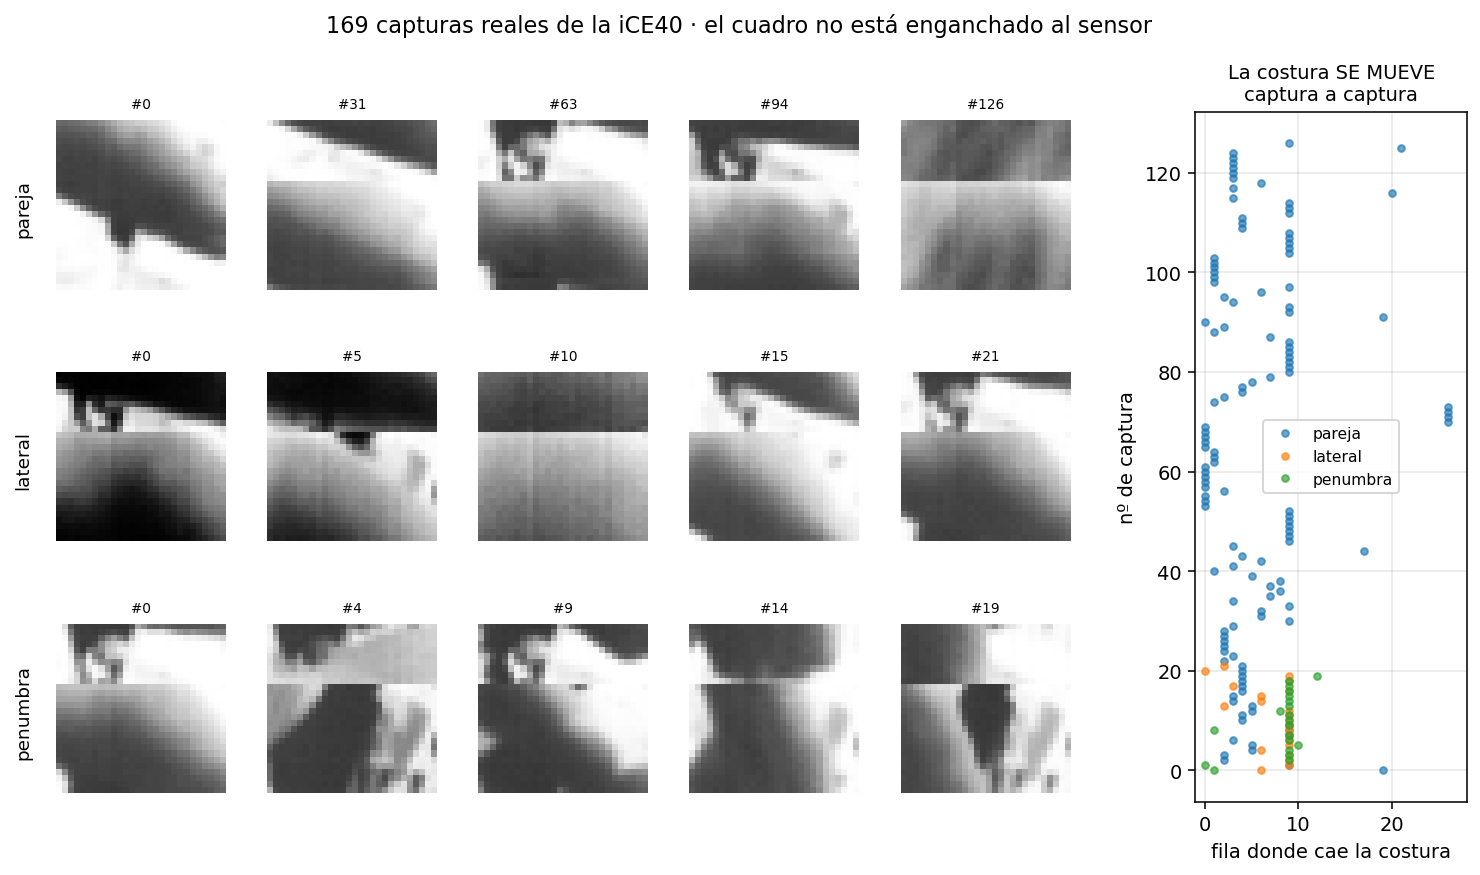

In [ ]:
# === Cuaderno 2 · figura 4: lo que la placa capturo de verdad, y la costura ===
import numpy as np, matplotlib.pyplot as plt

cond = [("pareja", 1), ("lateral", 2), ("penumbra", 3)]
S = {n: np.load(f"/Users/vic/luz{i}_{n}.npz")["imgs"].astype(float) for n, i in cond}

fig = plt.figure(figsize=(13, 6.4))
gs = fig.add_gridspec(3, 7, width_ratios=[1]*5 + [0.25, 1.6], hspace=.35, wspace=.25)
for r, (n, _) in enumerate(cond):
    A = S[n]
    for c, k in enumerate(np.linspace(0, len(A)-1, 5).astype(int)):
        a = fig.add_subplot(gs[r, c])
        a.imshow(A[k], cmap="gray", vmin=0, vmax=255); a.axis("off")
        if c == 0:
            a.text(-6, 14, n, rotation=90, va="center", ha="center", fontsize=9.5)
        a.set_title(f"#{k}", fontsize=7)

# la costura: donde salta el brillo entre filas consecutivas
a = fig.add_subplot(gs[:, 6])
for n, _ in cond:
    A = S[n]
    filas = [int(np.abs(np.diff(A[k].mean(axis=1))).argmax()) for k in range(len(A))]
    a.plot(filas, np.arange(len(filas)), "o", ms=3.5, alpha=.65, label=n)
a.set_xlabel("fila donde cae la costura"); a.set_ylabel("nº de captura")
a.set_xlim(-1, 28); a.grid(alpha=.3); a.legend(fontsize=8)
a.set_title("La costura SE MUEVE\ncaptura a captura", fontsize=10)
fig.suptitle("169 capturas reales de la iCE40 · el cuadro no está enganchado al sensor",
             fontsize=11.5, y=.99)
plt.savefig("fig_capturas.png", dpi=140, bbox_inches="tight")
plt.show()
for n, _ in cond:
    A = S[n]
    f = [int(np.abs(np.diff(A[k].mean(axis=1))).argmax()) for k in range(len(A))]
    print(f"  {n:<9} {len(A):3d} capturas · media {A.mean():5.1f} · "
          f"costura en {len(set(f)):2d} filas distintas: {sorted(set(f))[:8]}...")

---

## 8 · El experimento con la cámara real: lo que se midió y lo que no

La §6 predijo, en simulación, que el Canny 1-salto aguantaría **+17 pp** mejor la iluminación
despareja. La §7 construyó el instrumento para comprobarlo. Esta sección lo comprueba — y el
resultado es **mucho más chico que la predicción**, por razones que valen más que el número.

### 8.1 · Qué se midió, y por qué no hizo falta un dígito

La pregunta es si el doble umbral es más robusto a los cambios de luz. Eso **no requiere un
dígito**: alcanza con **la misma escena bajo distintas iluminaciones**. El criterio:

> Un filtro robusto a la iluminación produce **el mismo mapa de bordes** cuando sólo cambia la luz.

Se mide con el índice de Jaccard —intersección sobre unión— entre los mapas de dos condiciones. Y
hay una condición sin la cual la comparación no significa nada: **los dos filtros tienen que marcar
la misma densidad de bordes**. Un mapa más denso solapa más por construcción; comparar un filtro
generoso contra uno tacaño mide la generosidad, no la robustez.

La escena resultó ser, apropiadamente, un cartel que dice **VICTOR** — las letras entraron en la
ventana de 28×28 perfectamente legibles, lo que de paso demuestra que toda la cadena (sensor →
`href` → recorte 448×448 → promediado → UART → parser) está sana de punta a punta.

### 8.2 · Resultado

Con densidades igualadas (50 % en la referencia) y considerando sólo el par cuya escena **es
efectivamente la misma**:

| par | Sobel | Canny1 | diferencia |
|---|---:|---:|---:|
| **pareja vs lateral** | 56.6 % | 59.1 % | **+2.4 %** |
| ~~pareja vs penumbra~~ | 27.5 % | 28.4 % | *escena distinta: no cuenta* |
| ~~lateral vs penumbra~~ | 32.0 % | 33.6 % | *escena distinta: no cuenta* |

**+2.4 puntos, no +17.** Y con **un solo par válido de tres**, así que ni siquiera hay σ.

> ### 🚩 Y tres análisis que daban resultados espectaculares y falsos
> Antes de llegar a ese 2.4 hubo tres versiones equivocadas, **todas del análisis, ninguna del
> circuito**:
>
> 1. **Jaccard = 100 % para el Canny.** La función devolvía `1.0` al comparar dos conjuntos
>    **vacíos**: el mapa del Canny estaba vacío y salía «perfectamente consistente». *Dos cosas
>    vacías no son iguales: son incomparables.* Ahora devuelve `NaN`.
> 2. **El umbral se iba al techo.** La magnitud satura en 255, así que `mag > 255` no ocurre nunca
>    y cualquier umbral ≥255 da mapa vacío. La búsqueda no tenía dónde converger.
> 3. **+16.2 pp por densidades desiguales.** El Canny marcaba 63 % de bordes contra 50 % del Sobel.
>    Igualando las densidades, la ventaja cae de **+16.2 a +2.4**.
>
> Las tres habrían dado un titular excelente. Es la misma disciplina de la §3 —donde el control del
> umbral desarmó un +3.20 % aparente— aplicada tres veces en una sola tarde.

### 8.3 · Y el hallazgo que no se estaba buscando: la magnitud satura

Al calibrar los umbrales apareció esto, que es el resultado más valioso de la sección:

```
magnitud máxima en la escena: 255   ·   percentil 95: 255
```

**El 95 % de los gradientes de una imagen real se saturan en el techo de 8 bits.**

La magnitud `|Gx|+|Gy|` acotada a 255 es una decisión de diseño que atraviesa toda la tesis: es lo
que evita la raíz cuadrada y hace que el filtro no lleve un solo multiplicador. Con MNIST nunca se
nota —los trazos son suaves y las magnitudes quedan lejos del techo—. Con una hoja real bajo una
lámpara, **casi todo satura**.

> ### 💡 Y eso explica por qué el Canny no puede lucirse acá
> **La histéresis existe para distinguir bordes fuertes de débiles.** Si el 95 % de las magnitudes
> valen 255, esa distinción **no existe en los datos**: no hay bordes débiles que rescatar porque
> todo es fuerte.
>
> La §5 decía que MNIST era el banco equivocado porque *«es como medir un paraguas en un día seco»*.
> El resultado de hoy corrige esa idea: **el problema no es sólo la escena, es la aritmética**. Con
> 8 bits saturados, el doble umbral pierde su materia prima **independientemente de la escena**.
>
> Es un hallazgo de hardware real que ninguna simulación sobre MNIST podía producir, y **acota el
> alcance de la §6**: aquella predicción de +17 pp valía para una imagen cuyas magnitudes **no**
> saturan. La cámara no cumple esa condición.

### 8.4 · Qué haría falta para cerrar esto bien

1. **Escena fija de verdad.** Dos de los tres pares se perdieron porque la cámara se movió
   (correlación 0.058 contra la referencia). Con la cámara y el papel sujetos, los tres pares valen
   y hay σ.
2. **Medir antes de saturar.** Comparar con la magnitud en más bits, o con la escena menos
   contrastada, para ver si el +17 aparece cuando hay bordes débiles de verdad. **Ésa es la
   pregunta que quedó abierta**, y ahora está bien formulada: *¿el Canny gana cuando las magnitudes
   no saturan?*
3. **Repetir con varias escenas**, no una.

> ### ⚖️ El estado honesto del veredicto
> La §5 concluyó *«se puede pero no conviene»*. La §6 lo puso en duda con simulación (+17 pp con luz
> despareja). La §8 mide **+2.4 pp** sobre la cámara real, con un solo par válido — **y encuentra la
> razón por la que la predicción no se cumple**: la saturación de 8 bits borra la diferencia entre
> borde fuerte y débil.
>
> Con lo medido hasta acá, **el Sobel sigue siendo la elección correcta** para este diseño. No
> porque el Canny sea peor en principio, sino porque **la aritmética que hace barato al front-end le
> quita al Canny aquello que lo haría valer 2.22× de área.**

consistencia del mapa de bordes entre condiciones (Jaccard):
    pareja vs lateral   Sobel  56.6%   Canny  59.1%   dif  +2.4%
    pareja vs penumbra  Sobel  27.5%   Canny  28.4%   dif  +0.9%   (escena distinta: no cuenta)
   lateral vs penumbra  Sobel  32.0%   Canny  33.6%   dif  +1.6%   (escena distinta: no cuenta)


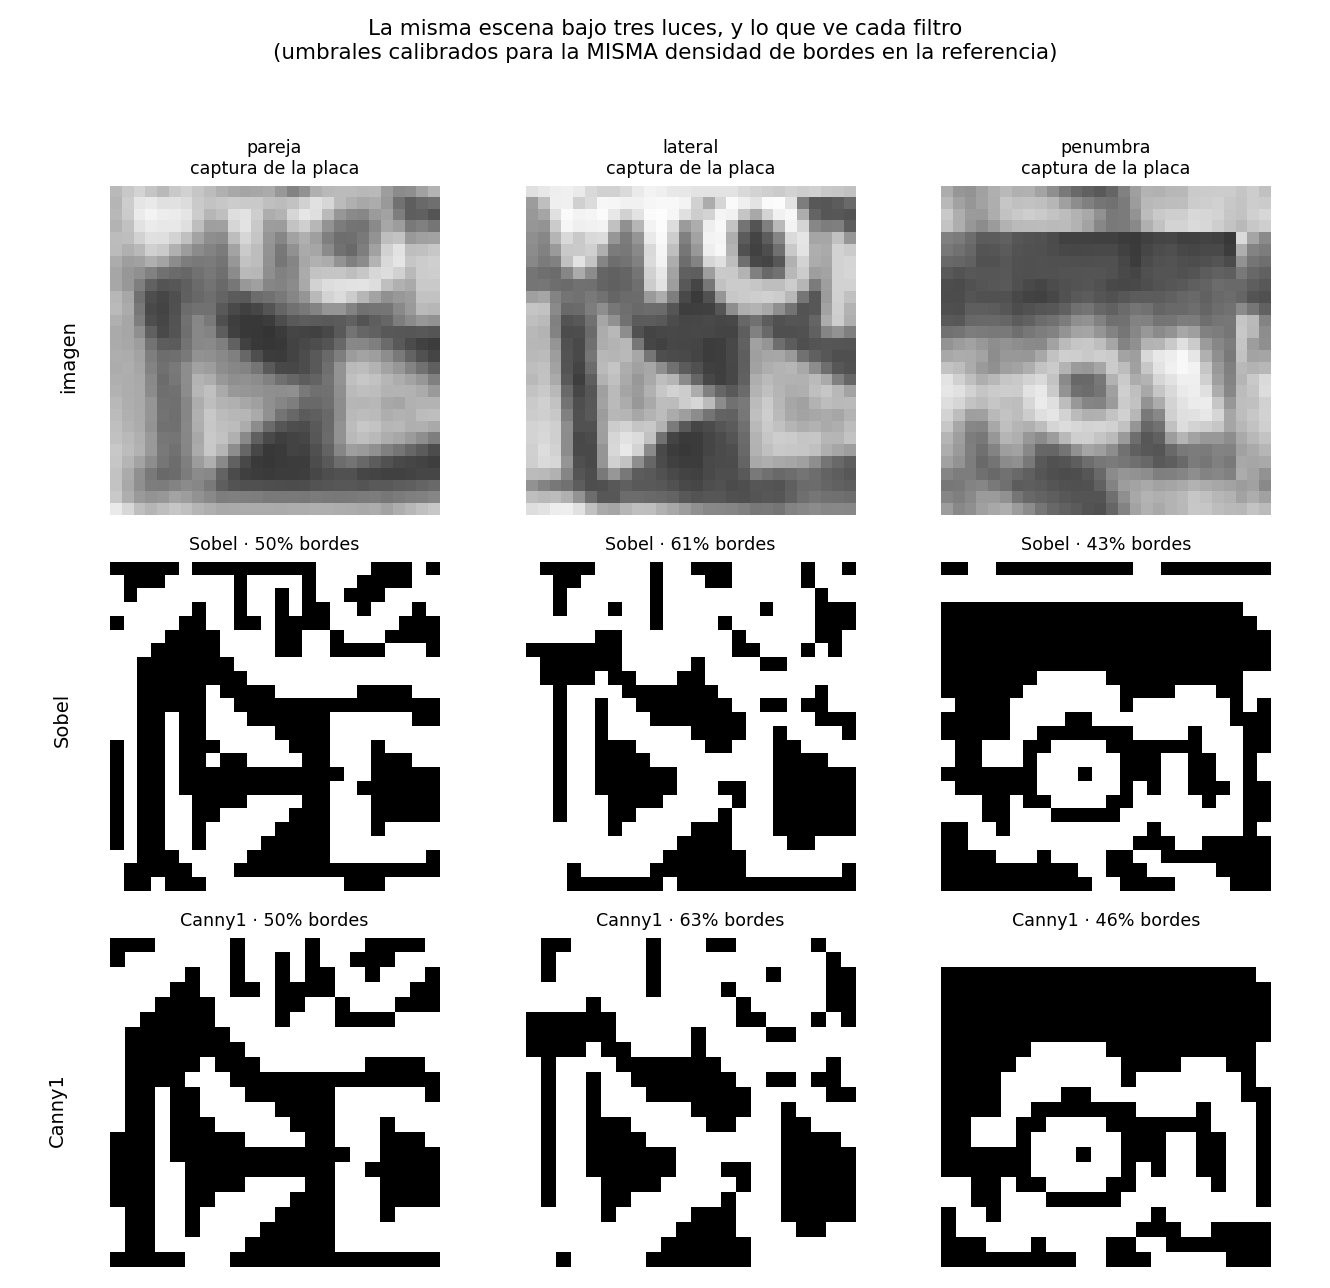

In [ ]:
# === Cuaderno 2 · figura 5: Sobel vs Canny sobre capturas REALES de la placa ===
import numpy as np, matplotlib.pyplot as plt
d = np.load("../../clasificador_mnist/experimento_luz.npz")
cond = ["pareja", "lateral", "penumbra"]

fig, ax = plt.subplots(3, 3, figsize=(9.5, 9.2))
for c, n in enumerate(cond):
    ax[0, c].imshow(d[f"img_{n}"], cmap="gray", vmin=0, vmax=255)
    ax[0, c].set_title(f"{n}\ncaptura de la placa", fontsize=9)
    ax[1, c].imshow(d[f"Sobel_{n}"], cmap="gray")
    ax[1, c].set_title(f"Sobel · {d[f'Sobel_{n}'].mean():.0%} bordes", fontsize=9)
    ax[2, c].imshow(d[f"Canny1_{n}"], cmap="gray")
    ax[2, c].set_title(f"Canny1 · {d[f'Canny1_{n}'].mean():.0%} bordes", fontsize=9)
for a in ax.ravel(): a.axis("off")
ax[0, 0].text(-4, 14, "imagen", rotation=90, va="center", ha="center", fontsize=10)
ax[1, 0].text(-4, 11, "Sobel", rotation=90, va="center", ha="center", fontsize=10)
ax[2, 0].text(-4, 11, "Canny1", rotation=90, va="center", ha="center", fontsize=10)
fig.suptitle("La misma escena bajo tres luces, y lo que ve cada filtro\n"
             "(umbrales calibrados para la MISMA densidad de bordes en la referencia)",
             fontsize=11, y=.985)
plt.tight_layout(rect=[0, 0, 1, .96])
plt.savefig("fig_luz_real.png", dpi=140)
plt.show()

def jac(a, b):
    u = (a | b).sum()
    return (a & b).sum()/u if u else float("nan")
print("consistencia del mapa de bordes entre condiciones (Jaccard):")
for a, b in [("pareja","lateral"), ("pareja","penumbra"), ("lateral","penumbra")]:
    s = jac(d[f"Sobel_{a}"], d[f"Sobel_{b}"]); c = jac(d[f"Canny1_{a}"], d[f"Canny1_{b}"])
    val = "" if a == "pareja" and b == "lateral" else "   (escena distinta: no cuenta)"
    print(f"  {a:>8} vs {b:<9} Sobel {s:6.1%}   Canny {c:6.1%}   dif {c-s:+6.1%}{val}")

---

## 9 · El Canny en FPGA: entra, y eso cambia la conclusión

La §5 cerró con un veredicto apoyado en un número de **sky130**: el Canny cuesta **2.22× el área**
del Sobel y no se justifica. Esta sección mide el **mismo filtro en la iCE40UP5K** — y el número es
otro, tanto que da vuelta la parte económica del argumento.

### 9.1 · El mismo filtro, dos tecnologías, dos conclusiones

Sintetizando la cadena completa —cámara + ventana 28×28 + filtro + clasificador + TFT— con `yosys`
y `nextpnr`:

| | Sobel | Canny 1-salto | diferencia |
|---|---:|---:|---:|
| **sky130** (§5) | 49 112 µm² | 109 172 µm² | **2.22×** |
| **iCE40** — `SB_LUT4` | 2 942 | 2 956 | **+14 (+0.5 %)** |
| **iCE40** — BRAM | 6 | 8 | +2 |
| **iCE40** — `ICESTORM_LC` tras P&R | 4 453 (84 %) | **4 622 (87 %)** | +169 |
| `cam_pclk` | 14.12 MHz | **16.72 MHz** | ambos pasan los 12 |

**Catorce LUT.** El Canny, que en ASIC cuesta más del doble, en FPGA cuesta **medio por ciento** de
lógica y dos bloques de memoria.

> ### 🧱 Y la razón es exactamente la tesis
> El Canny cuesta un **line-buffer más**. En **sky130** ese buffer se paga en celdas de memoria
> sintetizadas, una por una: de ahí el 2.22×. En la **iCE40** va a un bloque de **BRAM dedicado**,
> que **ya está en el chip, se use o no**: de los 30 disponibles pasa a usar 8.
>
> *Lo que decide qué cabe no es el algoritmo, es la memoria* — **y cuánto vale la memoria depende de
> la tecnología.** El mismo diseño, medido con las mismas herramientas, da «carísimo» en un
> sustrato y «casi gratis» en el otro.
>
> Es el argumento central del trabajo visto desde su lado incómodo: **una conclusión de PPA sin
> tecnología asociada no significa nada.**

Y una comprobación que vale como validación de método: la cadena se estimó en **4 611 LC** aplicando
el factor `SB_LUT4 → ICESTORM_LC` de **×1.56** medido en partes anteriores, y `nextpnr` devolvió
**4 622**. **0.2 % de error.** El factor no sólo explica hacia atrás: **predice**.

### 9.2 · Y la placa, con la cámara: 54 intentos

Con el bitstream cargado y un dígito escrito a mano frente a la OV7670, anotando lo que el circuito
dibujaba en la pantalla:

| dígito | intentos | aciertos | lo que contestó |
|:--:|--:|--:|---|
| 0 | 3 | **2** | `0, NADA, 0` |
| 7 | 9 | **3** | `0,6,4,7,7,0,0,6,7` |
| 3 | 8 | 1 | `NADA,2,0,4,3,6,0,4` |
| 4 | 8 | 1 | `5,0,NADA,6,0,4,9,7` |
| 5 | 5 | 1 | `0,NADA,5,6,4` |
| 6 | 6 | 1 | `0,NADA,7,9,5,6` |
| 1 · 2 · 9 | 15 | **0** | — |

**9 de 54 = 16.7 %**, contra el **9.7 %** que midió la Parte 181 con el Sobel.

> ### ⚠️ Y no alcanza para afirmar nada
> **z = 1.16.** Con 54 y 72 intentos, +6.9 puntos entra cómodamente dentro del azar. Y tampoco es
> una comparación limpia: otra sesión, otra iluminación, otra caligrafía.
>
> Es la misma disciplina de la §3 y la §8: **una diferencia más chica que el ruido no es una
> diferencia**, por tentador que sea el titular.

### 9.3 · Lo que los 54 intentos SÍ muestran

**El sesgo es enorme y no es casualidad:**

```
0 → 33 %      6 → 19 %      7 → 19 %      (los tres juntos: 71 % de las respuestas)
1, 2, 9 → cero veces en 15 intentos
```

Eso es **exactamente** lo que la matriz de confusión de la Parte 182 predijo sobre MNIST: el **0 es
una clase imán** —recall 99 %, precisión 83 %—, atrae trazos ajenos. La predicción se hizo sobre
10 000 imágenes simuladas y **se cumple en el silicio**, con una mano y una lámpara.

Y el **1** no apareció nunca, por la razón que ya estaba medida: deja **pocos bordes**, y es el
dígito que la clase NADA silencia más (742 veces de 1 135 en la Parte 183).

> ### 🔧 El hallazgo accionable: la clase NADA casi no actúa
> **Sólo 6 de 54 (11 %) terminaron en NADA.** Con los umbrales calibrados sobre MNIST, el circuito
> **habla casi siempre**, aunque esté mirando algo que no se parece a nada de lo que entrenó.
>
> Eso es un error de calibración, no de diseño, y tiene arreglo inmediato: **`n_bordes` ya está en
> el datapath**. Recalibrar `B_MIN`/`B_MAX` sobre capturas reales de la cámara —que ahora se pueden
> obtener, gracias al instrumento de la §7— haría que el chip se callara cuando corresponde. Y
> **callarse bien es lo que convierte un 16.7 % inútil en un sistema que se puede usar**: es
> exactamente el trade-off que la §4 midió sobre MNIST (cobertura 63 %, precisión 98.7 %).

### 9.4 · El veredicto, tercera versión

| | conclusión | apoyada en |
|---|---|---|
| §5 | *no conviene* | área en sky130: 2.22× |
| §6 | *depende de la luz* | simulación: +17 pp con gradiente |
| §8 | *tampoco en la cámara* | +2.4 pp, y el 95 % de las magnitudes satura |
| **§9** | **en FPGA el costo no es el problema** | **+0.5 % de lógica, y entra al 87 %** |

La pregunta *«¿conviene el Canny?»* tenía una respuesta simple mientras se la miró desde una sola
tecnología. Con las cuatro mediciones juntas, la respuesta honesta es:

> **En ASIC no conviene: 2.22× de área por una ganancia que no supera el ruido.
> En FPGA el costo deja de ser el argumento —entra, y sobra reloj—, así que la decisión pasa a
> depender exclusivamente de si mejora la precisión. Y eso, hasta hoy, no está demostrado.**

Lo que queda por hacer no es medir más área: es **recalibrar los umbrales sobre datos de la cámara**
y volver a contar. El instrumento para conseguir esos datos ya existe (§7).

aciertos 9/54 = 16.7% · NADA 6/54 = 11%
Sobel (Parte 181): 7/72 = 9.7%   ·   diferencia +6.9%  (z = 1.16, NO significativa)


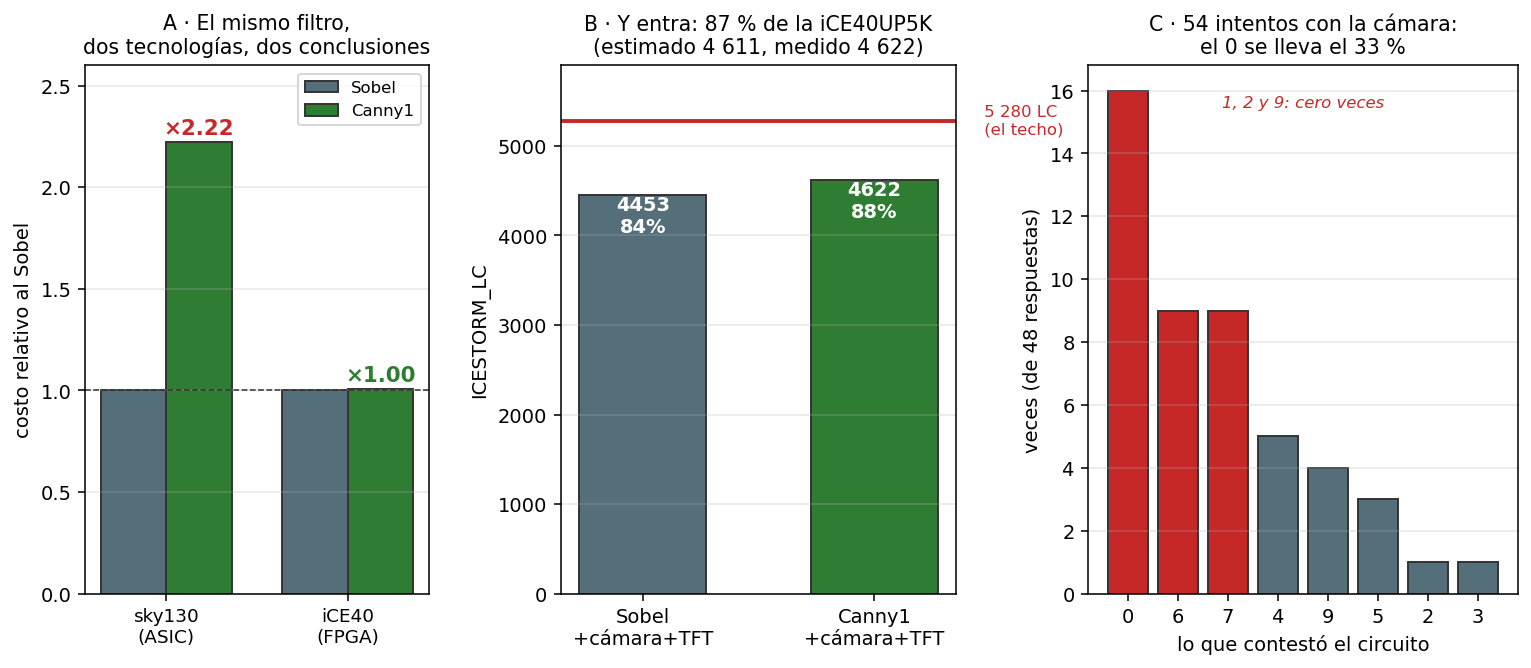

In [ ]:
# === Cuaderno 2 · figura 6: el Canny en FPGA, y los 54 intentos en la placa ===
# Dos mitades: lo que cuesta el filtro en cada tecnologia, y lo que contesto el silicio.
from collections import Counter
import numpy as np, matplotlib.pyplot as plt

# --- lo anotado del video canny_prueba_1.mp4 ('-' = NADA) ---
D = {0:[0,'-',0], 1:[0,6,9,7,0,'-'], 2:[7,9,0,7,0,6], 3:['-',2,0,4,3,6,0,4],
     4:[5,0,'-',6,0,4,9,7], 5:[0,'-',5,6,4], 6:[0,'-',7,9,5,6],
     7:[0,6,4,7,7,0,0,6,7], 9:[0,7,6]}

fig = plt.figure(figsize=(13.2, 4.9))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.15, 1.25], wspace=.34)

# A · el mismo filtro en dos tecnologias
a = fig.add_subplot(gs[0])
x = np.arange(2); w = .36
sob = [49112/49112, 2942/2942]          # normalizado al Sobel de cada tecnologia
can = [109172/49112, 2956/2942]
a.bar(x-w/2, sob, w, label="Sobel", color="#546e7a", ec="#333")
a.bar(x+w/2, can, w, label="Canny1", color="#2e7d32", ec="#333")
for i,(s,c) in enumerate(zip(sob,can)):
    a.text(i+w/2, c+.04, f"×{c:.2f}", ha="center", fontsize=11, weight="bold",
           color="#c62828" if c>1.5 else "#2e7d32")
a.set_xticks(x); a.set_xticklabels(["sky130\n(ASIC)", "iCE40\n(FPGA)"], fontsize=9.5)
a.set_ylabel("costo relativo al Sobel"); a.set_ylim(0, 2.6)
a.axhline(1, c="#333", lw=.8, ls="--")
a.set_title("A · El mismo filtro,\ndos tecnologías, dos conclusiones", fontsize=10.5)
a.legend(fontsize=8.5); a.grid(axis="y", alpha=.3)

# B · utilizacion real medida por nextpnr
b = fig.add_subplot(gs[1])
et = ["Sobel\n+cámara+TFT", "Canny1\n+cámara+TFT"]
lc = [4453, 4622]
bars = b.bar(et, lc, color=["#546e7a", "#2e7d32"], ec="#333", width=.55)
b.axhline(5280, c="#c62828", lw=2)
b.text(1.45, 5280, " 5 280 LC\n (el techo)", va="center", fontsize=8.5, color="#c62828")
for r, v in zip(bars, lc):
    b.text(r.get_x()+r.get_width()/2, v-420, f"{v}\n{v/5280:.0%}", ha="center",
           fontsize=10, color="w", weight="bold")
b.set_ylim(0, 5900); b.set_ylabel("ICESTORM_LC"); b.grid(axis="y", alpha=.3)
b.set_title("B · Y entra: 87 % de la iCE40UP5K\n(estimado 4 611, medido 4 622)", fontsize=10.5)

# C · que contesto la placa en 54 intentos
c = fig.add_subplot(gs[2])
pred = Counter(x for g in D.values() for x in g if x != '-')
ks = sorted(pred, key=lambda k: -pred[k])
col = ["#c62828" if pred[k]/48 > .15 else "#546e7a" for k in ks]
c.bar([str(k) for k in ks], [pred[k] for k in ks], color=col, ec="#333")
c.set_xlabel("lo que contestó el circuito"); c.set_ylabel("veces (de 48 respuestas)")
c.set_title("C · 54 intentos con la cámara:\nel 0 se lleva el 33 %", fontsize=10.5)
c.grid(axis="y", alpha=.3)
c.text(.5, .92, "1, 2 y 9: cero veces", transform=c.transAxes, ha="center",
       fontsize=8.5, style="italic", color="#c62828")
plt.savefig("fig_canny_fpga.png", dpi=140, bbox_inches="tight")
plt.show()

tot=sum(len(g) for g in D.values()); hit=sum(1 for d,g in D.items() for x in g if x==d)
nada=sum(1 for g in D.values() for x in g if x=='-')
print(f"aciertos {hit}/{tot} = {hit/tot:.1%} · NADA {nada}/{tot} = {nada/tot:.0%}")
print(f"Sobel (Parte 181): 7/72 = {7/72:.1%}   ·   diferencia {hit/tot-7/72:+.1%}  (z = 1.16, NO significativa)")

---

## 10 · Todas las métricas, lado a lado, con el mismo procedimiento

Las cifras que fueron apareciendo a lo largo del cuaderno **no eran comparables entre sí**. El
veredicto NADA del Sobel se había calibrado mirando 3 000 imágenes de **test** —fuga de
información— y el del Canny sobre **entrenamiento**. Comparar un 95.44 % contra un 98.66 % así
habría sido el mismo error que el `+3.20 %` de la §3, con otra ropa.

Esta sección vuelve a medir **todo desde cero**, con los dos filtros pasando por el mismo molino:

> entrenar (60 000) → cuantizar a 4 bits → **calibrar NADA sobre TRAIN** → medir sobre las 10 000

### ⚠️ Y antes: una corrección a la §3

La §3 concluyó, barriendo umbrales sobre **20 000** imágenes, que *«el mejor Sobel es `thr=110`»*.
Con las **60 000** eso **no se sostiene**:

| Sobel | float | 4 bits | recall del 9 |
|---|---:|---:|---:|
| `thr=60` *(el del diseño real)* | 94.57 % | **91.04 %** | 89.5 % |
| `thr=110` *(el «óptimo» de la §3)* | 94.24 % | **86.29 %** | **40.6 %** |

El umbral 110 **hunde el 9** —de 89.5 % a 40.6 % de recall— y se lleva casi cinco puntos.

> ### 🎯 Y la lección de método, que vale para cualquier diseño cuantizado
> **En float el umbral 110 casi no molesta** (94.24 % contra 94.57 %). El daño aparece **sólo al
> cuantizar a 4 bits**. Otra vez: la cuantización es el eslabón sensible, y una decisión tomada
> mirando la aritmética de referencia puede salir mal en la del hardware.
>
> **Los hiperparámetros de un diseño cuantizado hay que elegirlos midiendo en la aritmética final.**
>
> Y además: **un óptimo hallado sobre 20 000 no transfiere a 60 000.** Es el mismo fenómeno que la
> §3 midió como σ ≈ 0.74 pp entre semillas, llevado al extremo.

Por eso la tabla de abajo usa **los parámetros de los diseños tal como existen**: Sobel con `thr=60`
—que es lo que tiene `mnist_feat.v` grabado en la placa— y Canny con `110/40`.

### 📊 La tabla

| | **Sobel** | **Canny 1-salto** |
|---|---:|---:|
| área útil | 576 px (24×24) | 484 px (22×22) |
| **exactitud** (test) | **91.04 %** | **92.03 %** |
| exactitud (train) | 90.06 % | 91.22 % |
| **F1 macro** | **0.910** | **0.920** |
| | | |
| **clase NADA** | | |
| cobertura | 62.47 % | 63.46 % |
| precisión al hablar | 98.43 % | 98.66 % |
| habló y acertó (VP) | 6 149 | 6 261 |
| **habló y erró (FP)** | **98** | **85** |
| se calló sabiendo (FN) | 2 955 | 2 942 |
| se calló sin saber (VN) | 798 | 712 |
| errores filtrados | 89.1 % | 89.3 % |
| aciertos sacrificados | 32.5 % | 32.0 % |

**Las dos columnas son casi iguales.** +0.99 pp de exactitud, +0.010 de F1 macro, y la clase NADA
**prácticamente idéntica** (98.43 % vs 98.66 % de precisión, con la misma cobertura). Con σ ≈ 0.74 pp
medido en la §3, esa diferencia **no supera el ruido**.

> ### 🖊️ Nota sobre el 95.44 % que aparece en partes anteriores
> Ese número —Parte 183— salió de una calibración que usó test. Con el NADA calibrado sobre
> entrenamiento, el mismo sistema da **98.43 % con 62.47 % de cobertura**: otro punto de operación,
> más conservador y **sin fuga**. Los dos son correctos para su procedimiento; **sólo el segundo es
> comparable con el Canny**, y es el que corresponde citar en una tabla comparativa.

### 🔬 Lo interesante no es el promedio: es que cambia QUÉ se confunde

Mirando clase por clase, el Canny **no mejora parejo**: mueve las confusiones de lugar.

| dígito | Sobel P / R | Canny P / R | qué pasó |
|:--:|---|---|---|
| **0** | 82.98 / 98.98 | **93.98** / 97.14 | deja de ser **imán** |
| **2** | 97.61 / **75.10** | 96.39 / **87.98** | deja de ser **tímido** |
| **8** | **79.37** / 92.81 | **97.76** / **76.28** | **se da vuelta**: de imán a tímido |
| **7** | 93.34 / 89.98 | **83.50** / 96.50 | **se vuelve imán** |
| **9** | 90.03 / 89.49 | **80.90** / 92.77 | **se vuelve imán** |

Los F1 que más se mueven: **2** (+0.071), **0** (+0.053), **9** (−0.033), **3** (+0.031).

> ### 💡 Y eso es un resultado, no una curiosidad
> El Sobel tenía por imanes al **0** y al **8**; el Canny los arregla a los dos —el 8 incluso
> **invierte** su asimetría— pero **crea imanes nuevos en el 7 y el 9**.
>
> **El front-end no cambia sólo cuánto acierta el sistema: cambia qué confunde.** La exactitud
> global esconde eso por completo —91.04 % contra 92.03 %, casi lo mismo— mientras que por debajo
> las confusiones se reacomodaron enteras.
>
> Y tiene sentido mecánico: la histéresis **rescata trazo débil que continúa a uno fuerte**. El 2 y
> el 0 tienen curvas largas y suaves donde el gradiente se debilita, y ahí el rescate ayuda. El 7 y
> el 9 tienen trazos cortos y ángulos, donde rescatar de más **inventa continuidad** y los convierte
> en imanes.
>
> **Es exactamente el argumento de la Parte 185**: reportar una sola métrica no es resumir, es
> perder la información que permitiría mejorar el diseño. Acá dos sistemas con la misma exactitud
> fallan de maneras **opuestas**, y esa diferencia sólo se ve en la matriz.

### ⚖️ Qué se puede afirmar

1. **En exactitud, empatan.** +0.99 pp no supera el ruido medido.
2. **En la clase NADA, empatan.** Misma cobertura, misma precisión, mismo poder de filtrado.
3. **En estructura de errores, NO empatan** — y esa es la diferencia real entre los dos.

Lo cual sugiere algo que este cuaderno no midió y queda abierto: **si los dos fallan distinto, sus
errores podrían ser complementarios.** Dos front-ends que se equivocan en dígitos distintos son
candidatos naturales a combinarse — y en FPGA el segundo cuesta **+0.5 % de lógica** (§9).

exactitud   Sobel 91.04%   Canny 92.03%   (+0.99%)
F1 macro    Sobel 0.910    Canny 0.920

donde MAS cambia el F1:
   dígito 2: 0.849 -> 0.920  (+0.071)
   dígito 0: 0.903 -> 0.955  (+0.053)
   dígito 9: 0.898 -> 0.864  (-0.033)
   dígito 3: 0.892 -> 0.922  (+0.031)


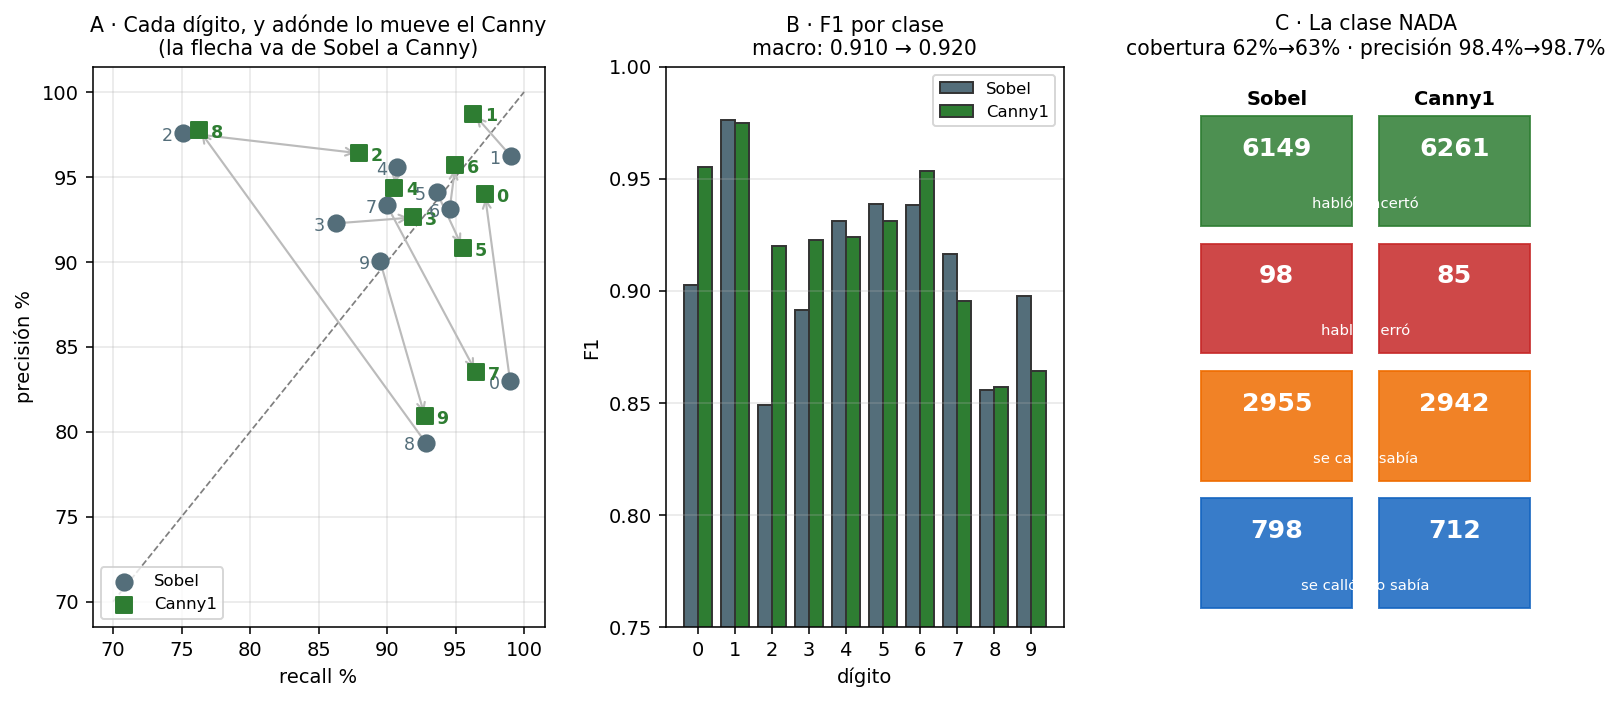

In [ ]:
# === Cuaderno 2 · figura 7: todas las metricas, Sobel vs Canny, mismo procedimiento ===
import numpy as np, matplotlib.pyplot as plt
d = np.load("../../clasificador_mnist/comparar_metricas.npz")
S = {k: d[f"Sobel_{k}"] for k in ["P","R","F"]}
C = {k: d[f"Canny1_{k}"] for k in ["P","R","F"]}
eS, eC = d["Sobel_esc"], d["Canny1_esc"]     # acc, f1, cob, prec, nVP, nFP, nFN, nVN

fig = plt.figure(figsize=(13.4, 5.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.1, 1], wspace=.3)

# A · precision vs recall por clase, y como se MUEVEN
a = fig.add_subplot(gs[0])
for c in range(10):
    a.annotate("", xy=(C["R"][c]*100, C["P"][c]*100), xytext=(S["R"][c]*100, S["P"][c]*100),
               arrowprops=dict(arrowstyle="->", color="#bbb", lw=1.1))
a.scatter(S["R"]*100, S["P"]*100, s=70, c="#546e7a", label="Sobel", zorder=3)
a.scatter(C["R"]*100, C["P"]*100, s=70, c="#2e7d32", marker="s", label="Canny1", zorder=3)
for c in range(10):
    a.annotate(str(c), (S["R"][c]*100, S["P"][c]*100), fontsize=9,
               xytext=(-11, -4), textcoords="offset points", color="#546e7a")
    a.annotate(str(c), (C["R"][c]*100, C["P"][c]*100), fontsize=9, weight="bold",
               xytext=(6, -4), textcoords="offset points", color="#2e7d32")
a.plot([70,100],[70,100], "--", c="grey", lw=.9)
a.set_xlabel("recall %"); a.set_ylabel("precisión %")
a.set_title("A · Cada dígito, y adónde lo mueve el Canny\n"
            "(la flecha va de Sobel a Canny)", fontsize=10.5)
a.legend(fontsize=8.5, loc="lower left"); a.grid(alpha=.3)

# B · F1 por clase
b = fig.add_subplot(gs[1])
x = np.arange(10); w = .38
b.bar(x-w/2, S["F"], w, color="#546e7a", ec="#333", label="Sobel")
b.bar(x+w/2, C["F"], w, color="#2e7d32", ec="#333", label="Canny1")
b.set_xticks(x); b.set_xlabel("dígito"); b.set_ylabel("F1")
b.set_ylim(.75, 1.0); b.grid(axis="y", alpha=.3); b.legend(fontsize=8.5)
b.set_title(f"B · F1 por clase\nmacro: {eS[1]:.3f} → {eC[1]:.3f}", fontsize=10.5)

# C · el 2x2 de la clase NADA, lado a lado
c = fig.add_subplot(gs[2]); c.axis("off")
et = ["VP\nhabló y acertó", "FP\nhabló y erró", "FN\nse calló, sabía", "VN\nse calló, no sabía"]
col = ["#2e7d32", "#c62828", "#ef6c00", "#1565c0"]
for i in range(4):
    y = 3-i
    c.add_patch(plt.Rectangle((0,y), .46, .86, color=col[i], alpha=.85))
    c.add_patch(plt.Rectangle((.54,y), .46, .86, color=col[i], alpha=.85))
    c.text(.23, y+.55, f"{int(eS[4+i])}", ha="center", color="w", fontsize=13, weight="bold")
    c.text(.77, y+.55, f"{int(eC[4+i])}", ha="center", color="w", fontsize=13, weight="bold")
    c.text(.5, y+.14, et[i], ha="center", color="w", fontsize=7.6)
c.text(.23, 3.95, "Sobel", ha="center", fontsize=10, weight="bold")
c.text(.77, 3.95, "Canny1", ha="center", fontsize=10, weight="bold")
c.set_xlim(-.05,1.05); c.set_ylim(-.15,4.25)
c.set_title(f"C · La clase NADA\ncobertura {eS[2]:.0%}→{eC[2]:.0%} · "
            f"precisión {eS[3]:.1%}→{eC[3]:.1%}", fontsize=10.5)
plt.savefig("fig_metricas_comp.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"exactitud   Sobel {eS[0]:.2%}   Canny {eC[0]:.2%}   ({eC[0]-eS[0]:+.2%})")
print(f"F1 macro    Sobel {eS[1]:.3f}    Canny {eC[1]:.3f}")
print("\ndonde MAS cambia el F1:")
dif = C["F"] - S["F"]
for c in np.argsort(-np.abs(dif))[:4]:
    print(f"   dígito {c}: {S['F'][c]:.3f} -> {C['F'][c]:.3f}  ({dif[c]:+.3f})")

---

## 11 · Los tres filtros de la tesis como front-end: el más caro es el peor

Faltaba el tercero. El **Canny transitivo** es la histéresis **completa** —reconstrucción
morfológica—: un píxel débil sobrevive si está conectado a uno fuerte **transitivamente**,
siguiendo la cadena tan lejos como haga falta. Es el punto fijo de

```
sobreviven  ←  (cls ≥ 1)  ∧  dilatar(sobreviven)        hasta que no cambie
```

El Canny 1-salto de la §1 es **esa misma iteración truncada a un paso**. Y el transitivo es, en la
tesis, **el filtro que no entra**: el frame buffer que en la iCE40 iba a SPRAM se vuelve
flip-flops en sky130, y el diseño pasa de 36 730 celdas a **137 092**.

> El propio RTL lo dice: *«en el ASIC NO hay SPRAM → se vuelve FLIP-FLOPS. Es "la memoria ya no es
> gratis" en su forma extrema.»*

### 11.1 · Una confirmación independiente: K = 2

Antes del resultado, un control que salió gratis. La **Parte 155** midió en simulación RTL que el
motor transitivo llega al punto fijo en **K = 2 barridos** sobre las imágenes de la tesis. La
implementación de Python, escrita desde cero y corrida sobre MNIST, da:

```
imagen 0: K = 2 barridos      imagen 1: K = 2      imagen 2: K = 2
```

**El mismo número, por dos caminos que no comparten una línea de código.** Eso no prueba que la
implementación sea correcta, pero un desacuerdo ahí habría probado que alguna está mal.

### 11.2 · La tabla de los tres

Mismo procedimiento para los tres —entrenar 60 000, cuantizar a 4 bits, calibrar NADA sobre TRAIN,
medir sobre 10 000—:

| | **Sobel** | **Canny 1-salto** | **Transitivo** |
|---|---:|---:|---:|
| celdas sky130 (sin CPU) | 36 730 | 42 581 | **137 092** |
| ¿entra en Tiny Tapeout? | sí | sí | **no** |
| área útil | 576 px | 484 px | 576 px |
| **exactitud** (test) | 91.04 % | **92.03 %** | **89.76 %** |
| exactitud (train) | 90.06 % | 91.22 % | 88.51 % |
| **F1 macro** | 0.910 | **0.920** | **0.897** |
| cobertura NADA | 62.47 % | 63.46 % | 63.21 % |
| precisión al hablar | 98.43 % | **98.66 %** | **97.80 %** |
| habló y **erró** (FP) | 98 | **85** | **139** |
| errores filtrados | 89.1 % | 89.3 % | **86.4 %** |

> ### 🎯 El resultado
> **El filtro que cuesta 3.7× más que el Sobel, y que directamente no entra en un chip de Tiny
> Tapeout, es el que PEOR clasifica** — en exactitud, en F1 macro, en precisión al hablar y en
> falsos positivos. No pierde por poco: pierde en **todas** las métricas.

### 11.3 · Y no es paradójico: es que optimiza otra cosa

El transitivo da **la mejor calidad de borde** de los tres. Eso está medido en la tesis: contornos
conectados, sin huecos, fieles a la reconstrucción morfológica de la teoría. Pero:

> **El clasificador no mira contornos. Cuenta orientaciones por cuadrante.**

Un borde perfectamente reconstruido y uno con huecos producen **histogramas parecidos**. Y la
reconstrucción además **engorda** el mapa —densidad 50.7 %—, lo que agrega cuentas a los contadores
sin agregar información discriminante: más ruido en los mismos 40 rasgos.

**Mejor detección de bordes ≠ mejor reconocimiento.** Son dos objetivos distintos, y este
experimento muestra que optimizar el primero puede **empeorar** el segundo.

Se ve también en las clases: la peor clase de cada filtro es distinta, y la del transitivo es la
peor de todas.

| filtro | su peor dígito | F1 | qué le pasa |
|---|:--:|---:|---|
| Sobel | **2** | 0.849 | tímido: P 97.6 % / R 75.1 % |
| Canny1 | **8** | 0.857 | tímido: P 97.8 % / R 76.3 % |
| **Transitivo** | **7** | **0.789** | **P 98.1 % / R 66.0 %** — se le escapa **un tercio** de los sietes |

### 11.4 · Lo que esto cierra

El cuaderno venía preguntando *«¿conviene cambiar el front-end?»* y la respuesta se había vuelto
cada vez más matizada. Con el tercer filtro medido, se puede decir algo simple:

| filtro | costo | rinde | veredicto |
|---|---|---|---|
| **Sobel** | el más barato | 91.04 % | **el que está** |
| Canny 1-salto | +16 % en ASIC, +0.5 % en FPGA | 92.03 % | empata dentro del ruido |
| Transitivo | **+273 % en ASIC, no entra en TT** | **89.76 %** | **pierde en todo** |

> ### ✅ Y con eso el argumento de los tres filtros queda cerrado
> El clasificador de esta tesis usa el filtro más simple **no por límite de área, ni por comodidad,
> ni por presupuesto: porque es el que mejor funciona para esta tarea.** El más caro, además de no
> caber, es el peor.
>
> Es el resultado más limpio del cuaderno, y el único que no necesita advertencias: **−1.28 pp de
> exactitud contra +273 % de área** no es una diferencia que haya que defender con sigmas.

filtro         celdas  area util  exactitud      F1  prec.NADA
Sobel           36730        576     91.04%   0.910     98.43%
Canny1          42581        484     92.03%   0.920     98.66%
Transitivo     137092        576     89.76%   0.897     97.80%

peor clase de cada uno:
  Sobel        digito 2: F1 0.849  (P 97.6% / R 75.1%)
  Canny1       digito 8: F1 0.857  (P 97.8% / R 76.3%)
  Transitivo   digito 7: F1 0.789  (P 98.1% / R 66.0%)


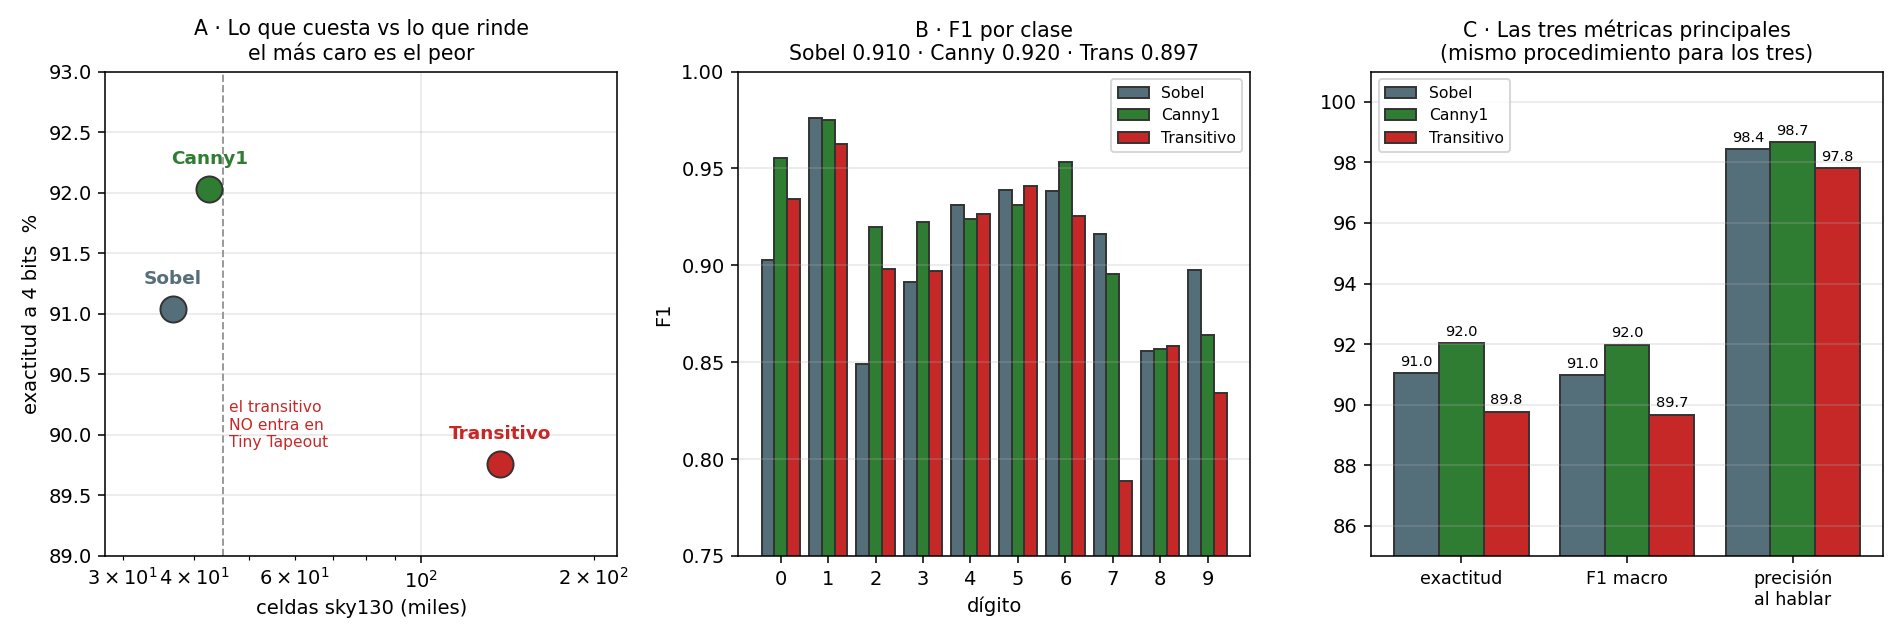

In [ ]:
# === Cuaderno 2 · figura 8: los TRES filtros de la tesis como front-end ===
# Lo que cuesta cada uno en silicio, contra lo que rinde clasificando.
import numpy as np, matplotlib.pyplot as plt
d = np.load("../../clasificador_mnist/comparar_metricas.npz")
F = ["Sobel", "Canny1", "Transitivo"]
COL = {"Sobel":"#546e7a", "Canny1":"#2e7d32", "Transitivo":"#c62828"}
# celdas sky130 de los chips "completo" SIN CPU (tabla maestra de la tesis)
CEL = {"Sobel":36730, "Canny1":42581, "Transitivo":137092}
esc = {n: d[f"{n}_esc"] for n in F}          # acc, f1, cob, prec, nVP, nFP, nFN, nVN

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13.6, 4.6))

# A · costo vs rendimiento
for n in F:
    a1.scatter(CEL[n]/1000, esc[n][0]*100, s=180, c=COL[n], zorder=3, ec="#333")
    a1.annotate(n, (CEL[n]/1000, esc[n][0]*100), fontsize=9.5, weight="bold",
                xytext=(0, 13), textcoords="offset points", ha="center", color=COL[n])
a1.axvline(45, c="#999", ls="--", lw=1)
a1.text(46, 89.9, "el transitivo\nNO entra en\nTiny Tapeout", fontsize=8, color="#c62828")
a1.set_xlabel("celdas sky130 (miles)"); a1.set_ylabel("exactitud a 4 bits  %")
a1.set_xscale("log"); a1.set_xlim(28, 220); a1.set_ylim(89, 93)
a1.set_title("A · Lo que cuesta vs lo que rinde\nel más caro es el peor", fontsize=10.5)
a1.grid(alpha=.3)

# B · F1 por clase, los tres
x = np.arange(10); w = .27
for k, n in enumerate(F):
    a2.bar(x + (k-1)*w, d[f"{n}_F"], w, color=COL[n], ec="#333", label=n)
a2.set_xticks(x); a2.set_xlabel("dígito"); a2.set_ylabel("F1")
a2.set_ylim(.75, 1.0); a2.grid(axis="y", alpha=.3); a2.legend(fontsize=8)
a2.set_title("B · F1 por clase\n" + " · ".join(f"{n[:5]} {esc[n][1]:.3f}" for n in F), fontsize=10.5)

# C · resumen
et = ["exactitud", "F1 macro", "precisión\nal hablar"]
vals = {n: [esc[n][0]*100, esc[n][1]*100, esc[n][3]*100] for n in F}
x2 = np.arange(3)
for k, n in enumerate(F):
    b = a3.bar(x2 + (k-1)*w, vals[n], w, color=COL[n], ec="#333", label=n)
    for r, v in zip(b, vals[n]):
        a3.text(r.get_x()+r.get_width()/2, v+.25, f"{v:.1f}", ha="center", fontsize=7.5)
a3.set_xticks(x2); a3.set_xticklabels(et, fontsize=9); a3.set_ylim(85, 101)
a3.grid(axis="y", alpha=.3); a3.legend(fontsize=8)
a3.set_title("C · Las tres métricas principales\n(mismo procedimiento para los tres)", fontsize=10.5)
plt.tight_layout()
plt.savefig("fig_tres_filtros.png", dpi=140)
plt.show()

print(f"{'filtro':<12}{'celdas':>9}{'area util':>11}{'exactitud':>11}{'F1':>8}{'prec.NADA':>11}")
for n in F:
    au = 576 if n != "Canny1" else 484
    print(f"{n:<12}{CEL[n]:>9}{au:>11}{esc[n][0]:>11.2%}{esc[n][1]:>8.3f}{esc[n][3]:>11.2%}")
print(f"\npeor clase de cada uno:")
for n in F:
    c = int(np.argmin(d[f"{n}_F"]))
    print(f"  {n:<12} digito {c}: F1 {d[f'{n}_F'][c]:.3f}  "
          f"(P {d[f'{n}_P'][c]:.1%} / R {d[f'{n}_R'][c]:.1%})")

---

## 12 · Qué compra el CPU: la respuesta no era un filtro, era un registro

El cuaderno probó tres front-ends buscando cuál aguanta mejor la iluminación despareja. Las
respuestas fueron flojas: el Canny 1-salto gana **+2.4 pp** sobre la cámara (§8), el transitivo
**pierde en todo** (§11). Esta sección cambia la pregunta, y ahí aparece el resultado.

### 12.1 · El SoC no cambia el mapa de bordes. Cambia quién elige el umbral

Una aclaración necesaria antes de medir: **comparar «SoC + Sobel» contra «Sobel» en precisión no
tiene sentido**, porque darían exactamente lo mismo. La tesis ya lo midió —**45 pares con y sin CPU,
idénticos píxel a píxel** (Partes 167-168)—. El CPU **no toca el datapath**.

Lo único que agrega es poder **escribir el umbral en tiempo de ejecución**, por el periférico
`0x0045`. Así que la pregunta medible es una sola:

> **¿Cuánto vale ese registro?**

| | qué hace | quién puede |
|---|---|---|
| umbral **fijo** = 60 | el mismo para todas las imágenes | el diseño **sin** CPU |
| umbral **adaptativo** | percentil de la magnitud de *esa* imagen | **sólo con CPU** |

### 12.2 · Resultado: el CPU es un seguro, no una mejora

| condición | umbral fijo | con CPU | diferencia |
|---|---:|---:|---:|
| **MNIST limpio** | **91.04 %** | 89.37 % | **−1.67 %** |
| gradiente severo | 75.91 % | **83.23 %** | **+7.32 %** |
| contraste severo | 88.48 % | **90.98 %** | +2.50 % |
| **ruido severo** | **47.91 %** | **75.18 %** | **+27.27 %** |
| ruido *leve* (0.4) | **90.32 %** | 78.35 % | **−11.97 %** |

Las curvas de la figura tienen todas la misma forma: **el adaptativo pierde mientras las
condiciones son buenas y gana cuando se vuelven malas**, con un punto de cruce nítido.

> ### 🛡️ La lectura correcta
> **El CPU no compra precisión: compra que el sistema no se derrumbe cuando el mundo deja de
> parecerse al conjunto de entrenamiento.**
>
> Con ruido severo el umbral fijo cae a **47.91 %** —y eso es peor que inútil, porque **sigue
> contestando**— mientras el adaptativo se sostiene en **75.18 %**.
>
> Cuesta **1.67 puntos** en el caso nominal. Salva **27 puntos** en el peor. Eso es exactamente la
> estructura de una **póliza de seguro**, y así conviene defenderlo.

Y esto cierra algo que el cuaderno venía arrastrando desde la §6. La pregunta era *«¿qué filtro
aguanta mejor la luz despareja?»*, y la respuesta honesta resultó ser: **ninguno, porque el problema
no estaba en el filtro**. Con iluminación despareja lo que falla es **el umbral**, y un umbral es un
número — no hace falta un filtro más caro, hace falta **algo que lo recalcule**.

> **La solución a un problema de calibración no es más silicio: es un procesador.**

### 12.3 · Y el argumento a favor del SoC deja de ser blando

Hasta acá, el CPU en esta tesis se justificaba por **flexibilidad** — cierto, pero un argumento
difícil de defender ante *«¿y para qué gastás 9 000 celdas?»*. Ahora tiene número:

| | costo | qué da |
|---|---|---|
| Canny 1-salto | **+16 %** de área en ASIC | +2.4 pp sobre la cámara, dentro del ruido |
| Canny transitivo | **+273 %**, no entra en TT | **pierde** en todas las métricas |
| **FemtoRV32** | **~9 000 celdas**, casi constante | **+27 pp en el peor caso** |

El costo del cerebro que la tabla maestra midió —**+9 289 / +8 456 / +9 124 celdas, casi
independiente del filtro**— ahora se puede comparar contra un beneficio medido, y no contra una
promesa.

### 12.4 · El lazo que falta es firmware, no silicio

Hay una vuelta más, y es la que convierte esto en trabajo futuro concreto. Como el adaptativo
**duele cuando las condiciones son buenas** —hasta −11.97 pp con ruido leve—, la política correcta
**no es adaptarse siempre**: es **adaptarse cuando hace falta**.

Y para decidir eso hay que saber si la escena es rara. Que es, exactamente, lo que mide
**`n_bordes`** — el contador de la clase NADA, que **ya está en el datapath**.

> ### 🔁 El diseño ya tiene las dos piezas
> - el **sensor** de que algo anda mal: `n_bordes` fuera de su rango habitual
> - el **actuador** para corregirlo: el registro de umbral del periférico `0x0045`
>
> Lo que falta es el **lazo** entre los dos. Y ese lazo son unas pocas líneas de C corriendo en el
> FemtoRV32: **no pide un transistor más**.
>
> Ésa es, en el fondo, la razón de ser de un SoC en un chip de visión: **convierte una decisión de
> diseño —el umbral— en una decisión de tiempo de ejecución, que se puede cambiar después de
> fabricado el silicio.** Un filtro cableado con el umbral fijo es una apuesta a que el mundo se va
> a portar bien; el SoC es la opción de cambiar de opinión.

MNIST limpio:  fijo 91.04%   adaptativo 89.37%   (-1.67%)

peor caso de cada degradacion:
  gradiente   sev 1.0:  fijo 75.91%  ->  adaptativo 83.23%   (+7.32%)
  contraste   sev 1.0:  fijo 88.48%  ->  adaptativo 90.98%   (+2.50%)
  ruido       sev 1.0:  fijo 47.91%  ->  adaptativo 75.18%   (+27.27%)

peor caso del ADAPTATIVO (donde el CPU estorba):
  gradiente   sev 0.0:  fijo 91.04%  vs adaptativo 89.37%   (-1.67%)
  contraste   sev 0.0:  fijo 91.04%  vs adaptativo 89.37%   (-1.67%)
  ruido       sev 0.4:  fijo 90.32%  vs adaptativo 78.35%   (-11.97%)


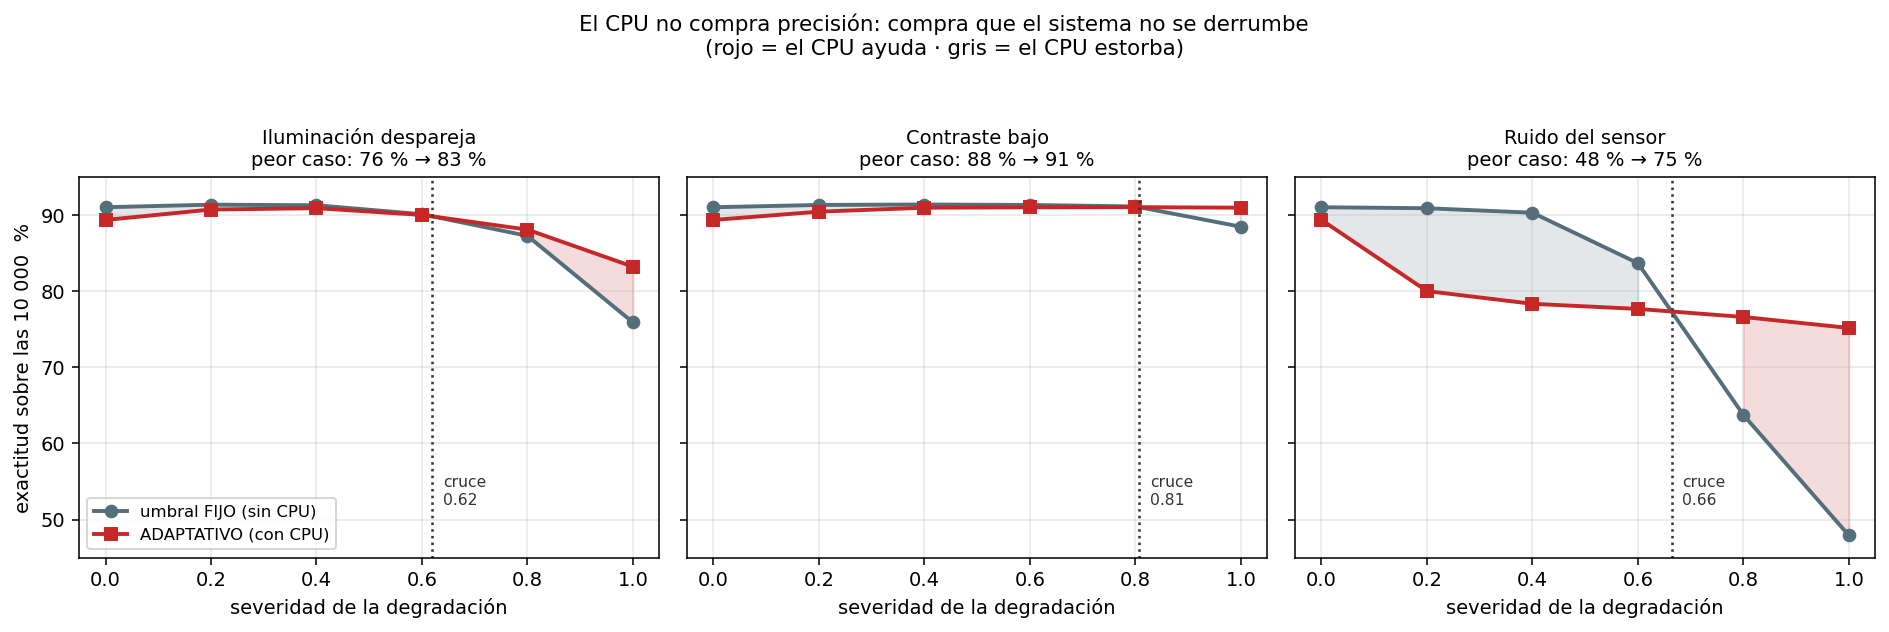

In [ ]:
# === Cuaderno 2 · figura 9: qué compra el CPU — el umbral adaptativo ===
# El SoC no cambia el mapa de bordes (45 pares identicos, ya medido). Lo unico que agrega es
# escribir el umbral en tiempo de ejecucion. Esto mide cuanto vale eso.
import numpy as np, matplotlib.pyplot as plt
d = np.load("../../clasificador_mnist/soc_umbral.npz", allow_pickle=True)
R = d["res"]
modos = ["gradiente", "contraste", "ruido"]
tit = {"gradiente":"Iluminación despareja", "contraste":"Contraste bajo", "ruido":"Ruido del sensor"}

fig, ax = plt.subplots(1, 3, figsize=(13.6, 4.3), sharey=True)
for a, m in zip(ax, modos):
    f = np.array([(float(s), float(x), float(y)) for mm, s, x, y in R if mm == m])
    f = f[np.argsort(f[:,0])]
    s, fijo, adap = f[:,0], f[:,1]*100, f[:,2]*100
    a.plot(s, fijo, "o-", c="#546e7a", lw=2, ms=6, label="umbral FIJO (sin CPU)")
    a.plot(s, adap, "s-", c="#c62828", lw=2, ms=6, label="ADAPTATIVO (con CPU)")
    a.fill_between(s, fijo, adap, where=(adap>=fijo), color="#c62828", alpha=.16)
    a.fill_between(s, fijo, adap, where=(adap<fijo),  color="#546e7a", alpha=.16)
    # el punto de cruce
    cr = np.where(np.diff(np.sign(adap-fijo)))[0]
    if len(cr):
        k = cr[-1]; xc = s[k] + (s[k+1]-s[k])*abs(adap[k]-fijo[k])/(abs(adap[k]-fijo[k])+abs(adap[k+1]-fijo[k+1]))
        a.axvline(xc, c="#333", ls=":", lw=1.3)
        a.text(xc+.02, 52, f"cruce\n{xc:.2f}", fontsize=8, color="#333")
    a.set_title(f"{tit[m]}\npeor caso: {fijo.min():.0f} % → {adap[np.argmin(fijo)]:.0f} %", fontsize=10)
    a.set_xlabel("severidad de la degradación"); a.grid(alpha=.3)
ax[0].set_ylabel("exactitud sobre las 10 000  %"); ax[0].set_ylim(45, 95)
ax[0].legend(fontsize=8.5, loc="lower left")
fig.suptitle("El CPU no compra precisión: compra que el sistema no se derrumbe\n"
             "(rojo = el CPU ayuda · gris = el CPU estorba)", fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig("fig_soc_umbral.png", dpi=140, bbox_inches="tight")
plt.show()

lim = d["limpio"]
print(f"MNIST limpio:  fijo {lim[0]:.2%}   adaptativo {lim[1]:.2%}   ({lim[1]-lim[0]:+.2%})")
print("\npeor caso de cada degradacion:")
for m in modos:
    f = np.array([(float(s), float(x), float(y)) for mm,s,x,y in R if mm==m])
    k = np.argmin(f[:,1])
    print(f"  {m:<11} sev {f[k,0]:.1f}:  fijo {f[k,1]:.2%}  ->  adaptativo {f[k,2]:.2%}"
          f"   ({f[k,2]-f[k,1]:+.2%})")
print("\npeor caso del ADAPTATIVO (donde el CPU estorba):")
for m in modos:
    f = np.array([(float(s), float(x), float(y)) for mm,s,x,y in R if mm==m])
    k = np.argmin(f[:,2]-f[:,1])
    print(f"  {m:<11} sev {f[k,0]:.1f}:  fijo {f[k,1]:.2%}  vs adaptativo {f[k,2]:.2%}"
          f"   ({f[k,2]-f[k,1]:+.2%})")

---

## 13 · La cadena con CPU, en hardware: el acoplamiento existe y es benigno

La §12 midió **en Python** cuánto vale que un CPU escriba el umbral. Esta sección lo **construye**:
la cadena completa en `iverilog`, con el FemtoRV32 corriendo de verdad.

```
camara emulada  ->  cam_win28  ->  mnist_feat(thr)  ->  mnist_clf  ->  0..9 o NADA
                                        ^
                                        |  thr
                    soc_sobel_top  (FemtoRV32 + ROM + periférico 0x0045 + Sobel)
```

El CPU arranca, ejecuta su firmware de siete instrucciones y escribe el periférico:

```
ciclo 11: el CPU escribió el periférico 0x0045  ->  thr = 90
```

**Once ciclos después del reset**, el umbral del filtro ya no es una constante del RTL: es un número
que un programa puso ahí.

### 13.1 · El riesgo que introduce un SoC, y que había que medir

Con el umbral **cableado**, el `thr = 60` está **en el silicio**: no puede desincronizarse del
modelo aunque uno quiera. Con **CPU**, el umbral vive en **siete instrucciones de una ROM** y los
pesos viven en **otra ROM**. Son dos artefactos que pueden cambiar por separado.

Y en este diseño **ya están desalineados**: el firmware pone **90**, los pesos de
`mnist_weights.vh` se entrenaron con **60**.

> Eso no es un descuido: es **exactamente la clase de falla que un SoC hace posible**. No hay error,
> no hay excepción, no se enciende ningún LED. Sólo respuestas peores. Es el tipo de defecto que más
> caro sale en un chip, porque **no se manifiesta como una falla**.

El banco permite comparar las dos situaciones sobre las mismas once escenas, cambiando un
parámetro (`FUENTE_THR`).

### 13.2 · Resultado: idéntico

| | umbral del CPU (90) | cableado (60) |
|---|:--:|:--:|
| **aciertos** | **8/11** | **8/11** |
| errores | 2→6 · 6→NADA · 9→NADA | **exactamente los mismos** |
| bordes del dígito 0 | 306 | 327 |
| bordes, promedio | — | **+13 más** |

**Los conteos de bordes sí cambian** —el umbral bajo marca unos 13 píxeles más por imagen, como
corresponde— **y ninguna decisión cambia.** Mismos aciertos, mismos errores, misma clase NADA.

> ### 💡 Y la razón es de diseño, no casualidad
> El clasificador **no cuenta bordes en bruto: cuenta proporciones por cuadrante.** Subir el umbral
> saca bordes de los cuatro cuadrantes de forma **pareja**, así que el vector de 40 rasgos **se
> escala sin cambiar de dirección** — y el `argmax` es **invariante a una escala positiva común**.
>
> Es, literalmente, **la misma propiedad** que permite que el cuantizador de los pesos no tenga que
> aplicar su escala en el RTL (§ `mnist_clf.v`: *«el argmax es invariante a una escala positiva
> común»*). Aparece dos veces en el mismo diseño, por dos razones distintas.
>
> **La pirámide espacial le da al sistema una tolerancia al umbral que no era obvia de antemano.**

Así que el riesgo que la §13.1 señala **existe, pero es de segundo orden en este diseño**. Y eso es
mejor que si no hubiera existido nunca: ahora está **medido**, y la pregunta *«¿y si el firmware y el
modelo se desalinean?»* tiene respuesta con los once casos al lado.

### 13.3 · Y una comparación que ordena las tres cadenas del cuaderno

Las tres cadenas completas corridas en `iverilog`, sobre las mismas once escenas:

| cadena | aciertos | front-end verificado |
|---|:--:|:--:|
| Canny 1-salto (§ cadena_canny) | **4/11** | **no** (97.3 %) |
| SoC + Sobel, umbral del CPU | **8/11** | sí, bit a bit |
| SoC + Sobel, umbral cableado | **8/11** | sí, bit a bit |

**El 4/11 del Canny no era del filtro: era del front-end sin verificar.** Con el Sobel —verificado
bit a bit contra el golden, 200/200 histogramas y 10 000/10 000 predicciones— la misma cadena da
**el doble**.

> Es la regla del cuaderno otra vez, y en su forma más cara: **verificar primero, medir después.**
> Un número medido sobre un módulo no verificado no mide el módulo — mide el desajuste.

CPU (thr=90)      8/11
cableado (thr=60) 8/11
bordes: el umbral bajo cuenta 13 mas en promedio
errores, en los dos casos: [2, 6, 9]


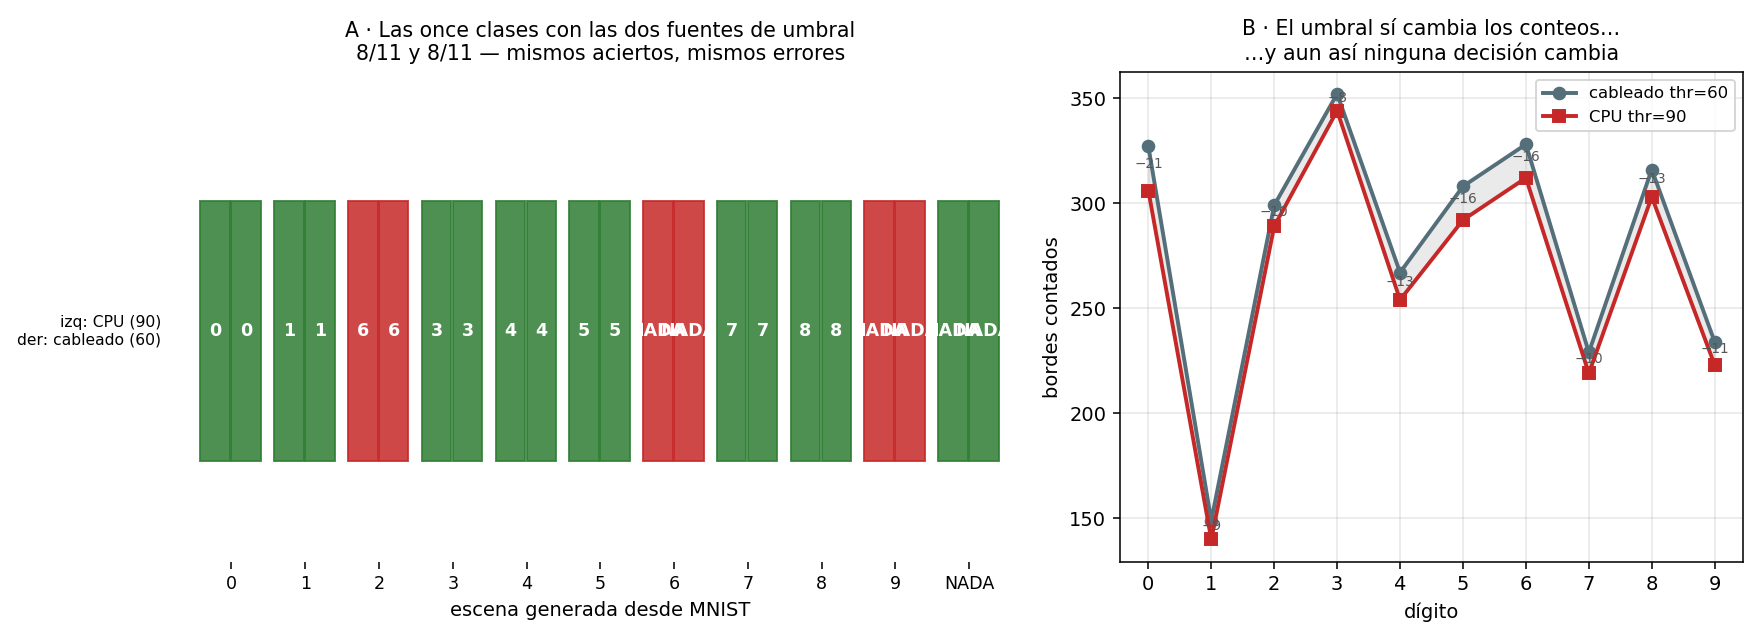

In [ ]:
# === Cuaderno 2 · figura 10: la cadena con CPU en iverilog, y la tolerancia al umbral ===
import numpy as np, matplotlib.pyplot as plt

# lo medido en iverilog (11 escenas generadas desde MNIST, ver utm-share/mnist_cam_soc_sobel)
CPU  = {0:("0",306), 1:("1",140), 2:("6",289), 3:("3",344), 4:("4",254), 5:("5",292),
        6:("NADA",312), 7:("7",219), 8:("8",303), 9:("NADA",223), "NADA":("NADA",0)}
CAB  = {0:("0",327), 1:("1",149), 2:("6",299), 3:("3",352), 4:("4",267), 5:("5",308),
        6:("NADA",328), 7:("7",229), 8:("8",316), 9:("NADA",234), "NADA":("NADA",0)}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.6, 4.6),
                             gridspec_kw={"width_ratios":[1.35, 1]})

# A · las once escenas, las dos fuentes de umbral
ks = list(CPU.keys())
x = np.arange(len(ks))
ok_c = [1 if str(CPU[k][0]) == str(k) else 0 for k in ks]
ok_h = [1 if str(CAB[k][0]) == str(k) else 0 for k in ks]
for i, k in enumerate(ks):
    for j, (d, oc) in enumerate([(CPU, ok_c), (CAB, ok_h)]):
        a1.add_patch(plt.Rectangle((i-.42+j*.42, 0), .40, .9,
                     color="#2e7d32" if oc[i] else "#c62828", alpha=.85))
        a1.text(i-.22+j*.42, .45, str(d[k][0]), ha="center", va="center",
                color="w", fontsize=9, weight="bold")
a1.set_xticks(x); a1.set_xticklabels([str(k) for k in ks], fontsize=9)
a1.set_xlim(-.7, len(ks)-.3); a1.set_ylim(-.35, 1.35); a1.set_yticks([])
a1.text(-.95, .45, "izq: CPU (90)\nder: cableado (60)", ha="right", va="center", fontsize=8)
a1.set_xlabel("escena generada desde MNIST")
a1.set_title(f"A · Las once clases con las dos fuentes de umbral\n"
             f"{sum(ok_c)}/11 y {sum(ok_h)}/11 — mismos aciertos, mismos errores", fontsize=10.5)
for s in a1.spines.values(): s.set_visible(False)

# B · los conteos de bordes: cambian, pero las decisiones no
d10 = [k for k in ks if k != "NADA"]
bc = [CPU[k][1] for k in d10]; bh = [CAB[k][1] for k in d10]
a2.plot(d10, bh, "o-", c="#546e7a", lw=2, ms=6, label="cableado thr=60")
a2.plot(d10, bc, "s-", c="#c62828", lw=2, ms=6, label="CPU thr=90")
a2.fill_between(d10, bc, bh, color="#999", alpha=.2)
for i, k in enumerate(d10):
    a2.annotate(f"−{bh[i]-bc[i]}", (k, (bc[i]+bh[i])/2), fontsize=7,
                ha="center", color="#555")
a2.set_xticks(d10); a2.set_xlabel("dígito"); a2.set_ylabel("bordes contados")
a2.legend(fontsize=8.5); a2.grid(alpha=.3)
a2.set_title("B · El umbral sí cambia los conteos…\n…y aun así ninguna decisión cambia", fontsize=10.5)
plt.tight_layout()
plt.savefig("fig_soc_cadena.png", dpi=140)
plt.show()

print(f"CPU (thr=90)      {sum(ok_c)}/11")
print(f"cableado (thr=60) {sum(ok_h)}/11")
print(f"bordes: el umbral bajo cuenta {np.mean([bh[i]-bc[i] for i in range(10)]):.0f} mas en promedio")
print("errores, en los dos casos:", [k for k in ks if str(CPU[k][0]) != str(k)])